# Genomic Variant Pathogenicity Prediction Pipeline
This notebook documents the development, tuning, and validation of an XGBoost-based machine learning model to classify genomic variants as Benign or Pathogenic using ClinVar data and various functional scoring metrics.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1. Data Acquisition and Environment Setup
We begin by mounting Google Drive to access our clinical datasets and importing the necessary libraries for data manipulation and visualization.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/AI_WES_AD_Project/Feature Eng/Clinvar_label(4.7k).csv")

print("Original shape:", df.shape)
print("Total original columns:", len(df.columns))

Original shape: (4745, 33)
Total original columns: 33


### 2. Feature Selection and Preprocessing
In this step, we focus on eight critical genomic features covering allele frequency, functional impact, and evolutionary conservation. We also map the complex ClinVar significance labels into a binary classification target.

In [ ]:
# Install if needed
!pip install pandas numpy scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [ ]:
# Replace dot strings with actual NaN values across the whole dataframe
df.replace('.', np.nan, inplace=True)

# Identify and convert columns to numeric where possible
for col in df.columns:
    # Attempt to convert to numeric, non-numeric values become NaN if they were still strings
    df[col] = pd.to_numeric(df[col], errors='ignore')

/tmp/ipykernel_3854/3409718878.py:7: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [ ]:
features = [
    "gnomAD_exome_ALL",
    "SIFT_score",
    "Polyphen2_HVAR_score",
    "CADD_phred",
    "REVEL_score",
    "VEST4_score",
    "phyloP100way_vertebrate",
    "GERP++_RS",
]

target = "CLNSIG"
# Create the subset
df = df[features + [target]].copy()

In [ ]:
# Normalize text for mapping
df[target] = df[target].astype(str).str.lower()

# Map to binary labels
label_map = {
    'pathogenic': 1,
    'likely_pathogenic': 1,
    'pathogenic/likely_pathogenic': 1,
    'pathogenic/likely_pathogenic/pathogenic\\x2c_low_penetrance': 1,
    'pathogenic/likely_pathogenic|risk_factor': 1,
    'benign': 0,
    'likely_benign': 0,
    'benign/likely_benign': 0,
    'benign/likely_benign|drug_response': 0,
    'benign/likely_benign|other|risk_factor': 0,
    'benign/likely_benign|drug_response|other': 0
}

df["label"] = df[target].map(label_map)
print("Shape:", df.shape)
print("Label counts:")
print(df["label"].value_counts())

Shape: (4745, 10)
Label counts:
label
0    4521
1     224
Name: count, dtype: int64


### 2.2 Feature Engineering: Imputation & Scaling
To ensure our machine learning models perform optimally, we must address two key data quality issues:

1.  **Missing Values**: Genomic scores like SIFT or VEST4 often have missing entries if a variant falls outside the tool's coverage. We use **Median Imputation** to fill these gaps without introducing extreme outliers.
2.  **Feature Scaling**: Since our features have vastly different ranges (e.g., gnomAD frequency is [0, 1] while CADD can be [0, 60+]), we apply **Standard Scaling** (Z-score normalization). This ensures no single feature dominates the model's weight purely due to its magnitude.

In [ ]:
from sklearn.metrics import accuracy_score

# Prepare features and target
X = df[features].copy()
y = df["label"]

# Handle missing values using median imputation
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize and train the Random Forest Classifier
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

# Model evaluation
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Train size: (3796, 8)
Test size: (949, 8)

Accuracy: 0.9747102212855637
ROC AUC: 0.960275319567355

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       904
           1       0.80      0.62      0.70        45

    accuracy                           0.97       949
   macro avg       0.89      0.81      0.84       949
weighted avg       0.97      0.97      0.97       949



### 3. Initial Model Benchmarking
We evaluate several standard classifiers—Random Forest, Logistic Regression, and SVM—to establish a performance baseline before moving to advanced gradient boosting.

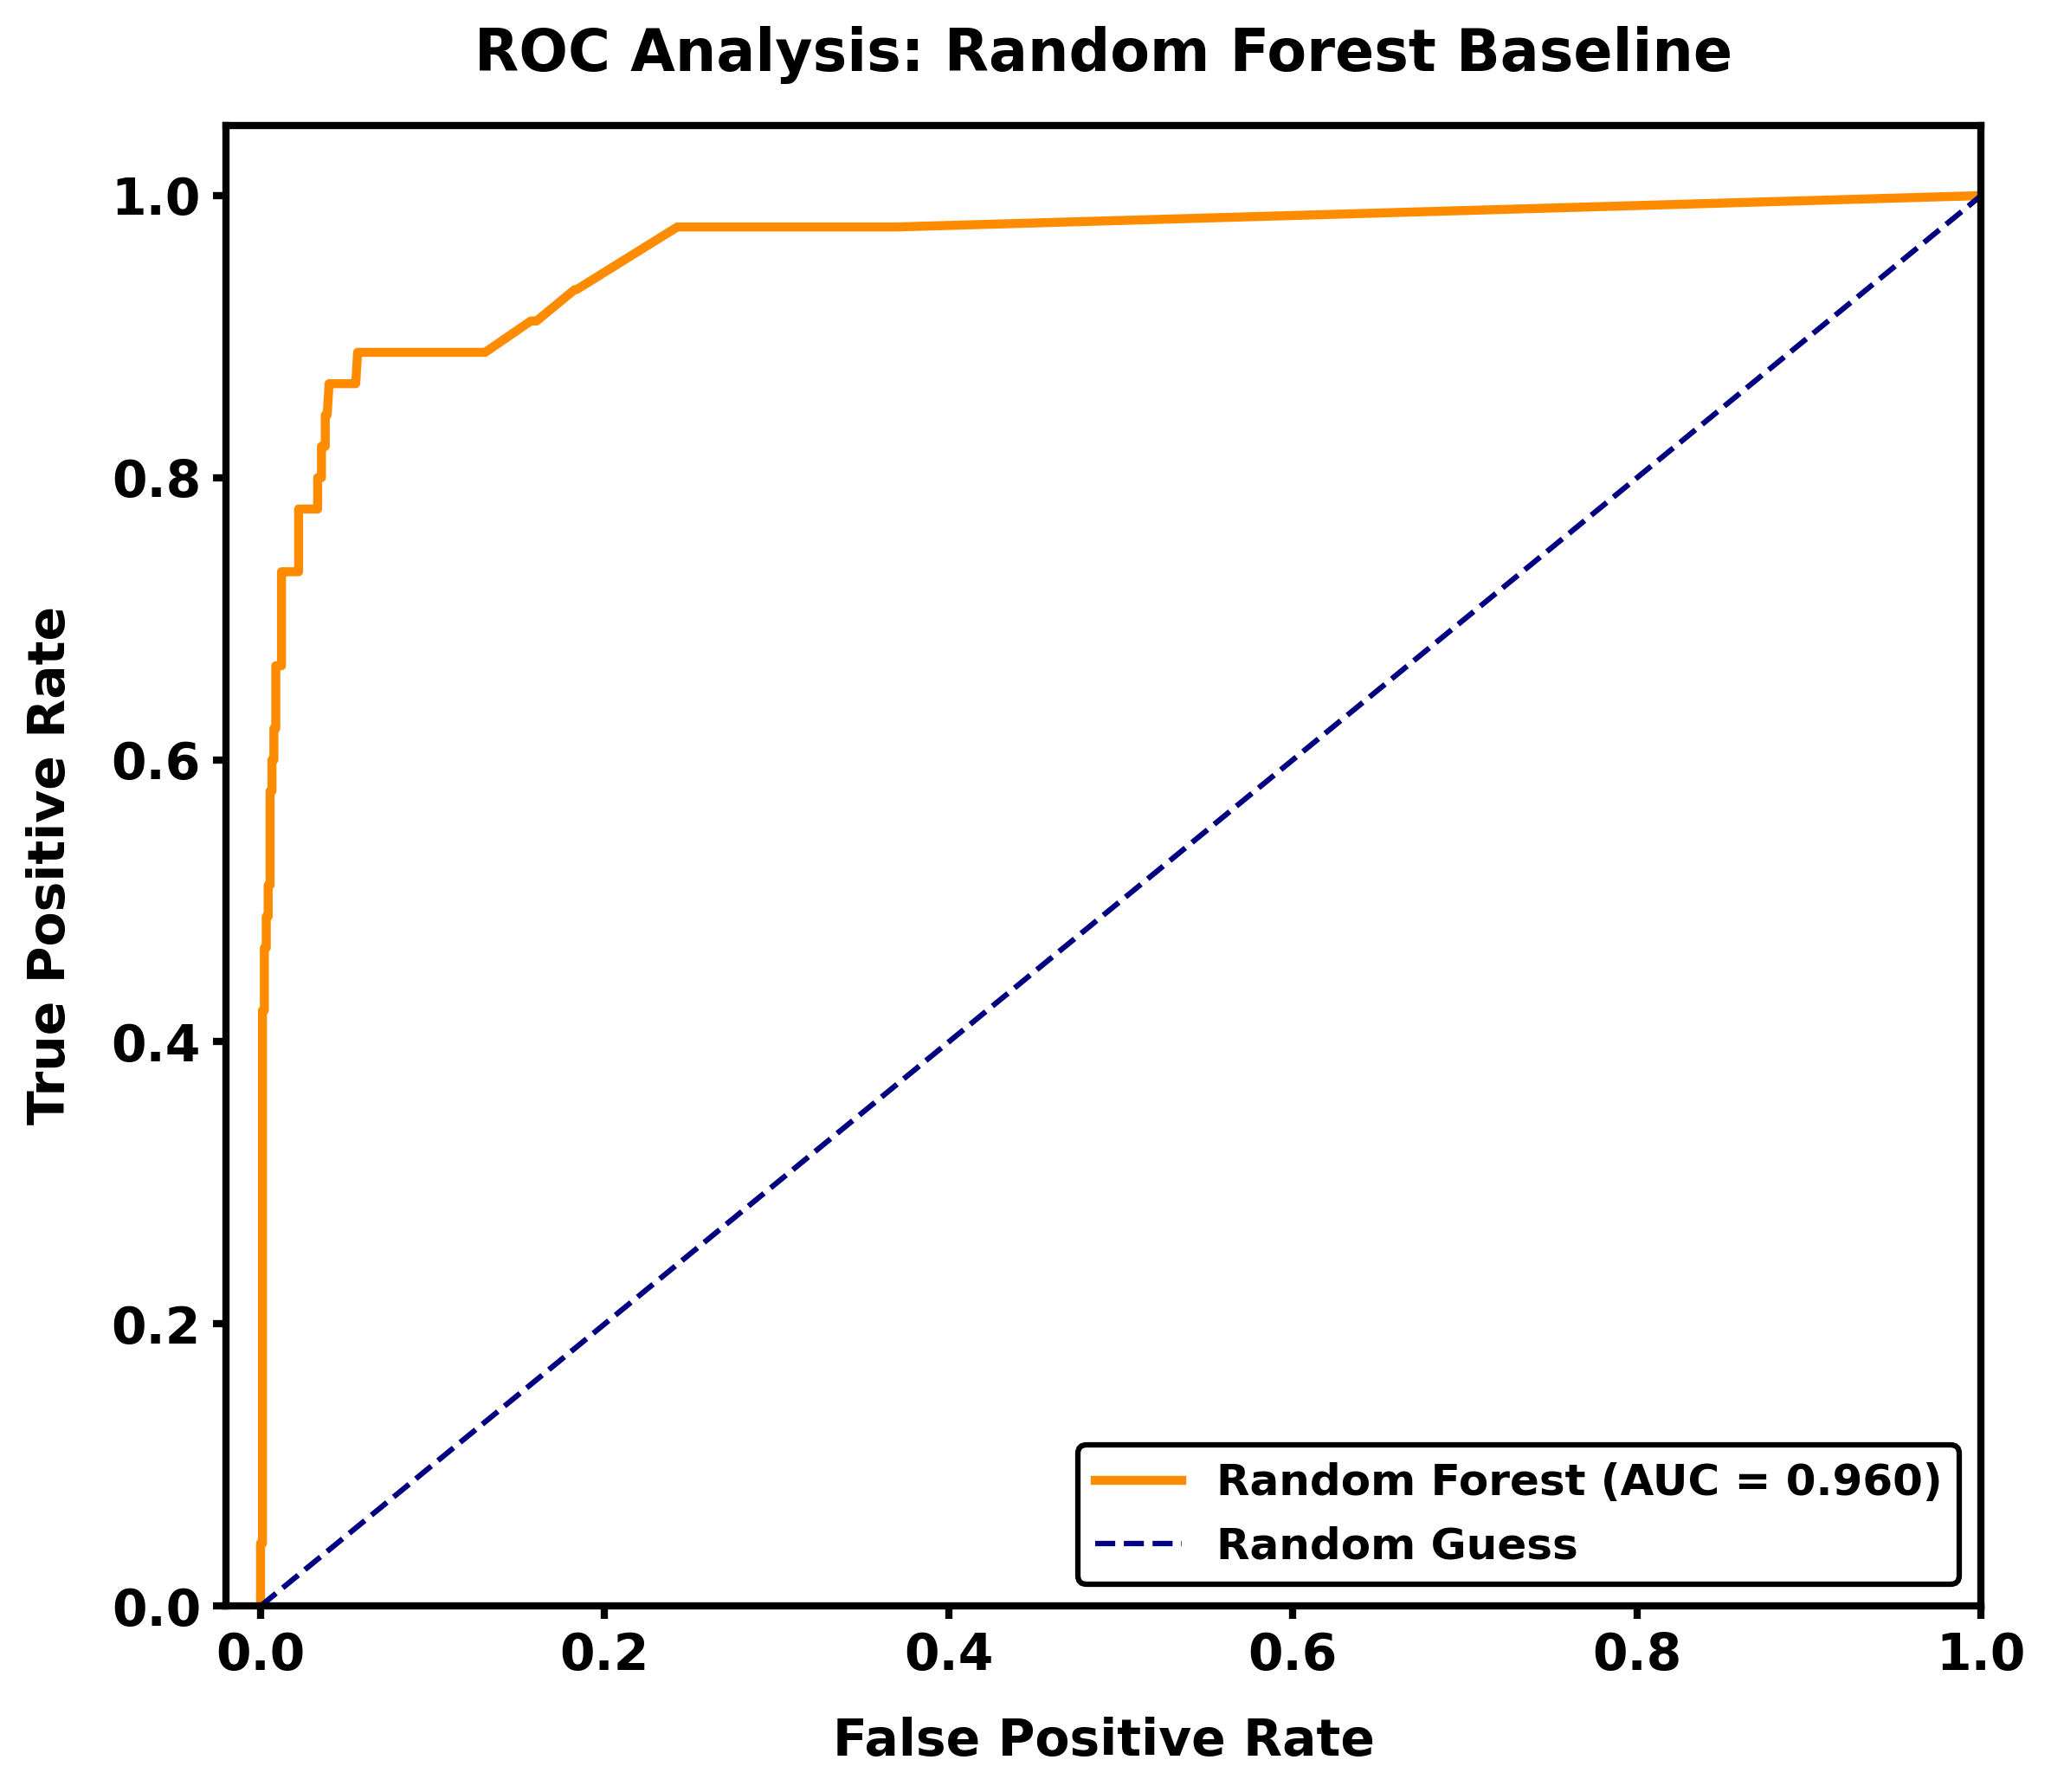

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve metrics
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# 1. Remove all background grids by using plt.style.use('default')
plt.style.use('default')

# 2. Set the inline figure DPI to 300
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# Plotting the ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'Random Forest (AUC = {roc_auc:.3f})')

# Plotting the diagonal baseline
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')

# 3. Add a thick, solid black border around the entire plot axis (linewidth 2.0)
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_edgecolor('black')

# 4. Axis labels, tick labels, and titles: bold, size 14+, strictly black
ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold', color='black', labelpad=10)
ax.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold', color='black', labelpad=10)
ax.set_title('ROC Analysis: Random Forest Baseline', fontsize=16, fontweight='bold', color='black', pad=15)

# Format tick labels to be bold and black
ax.tick_params(axis='both', which='major', labelsize=14, colors='black', width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

# 5. Include a legend with a solid black frame (linewidth 1.5) and bold black text
legend = ax.legend(loc="lower right", frameon=True, fontsize=12)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1.5)
legend.get_frame().set_alpha(1.0)

for text in legend.get_texts():
    text.set_fontweight('bold')
    text.set_color('black')

ax.set_xlim([-0.02, 1.0])
ax.set_ylim([0.0, 1.05])
plt.tight_layout()

# 6. Save the figure with 600 DPI and tight layout
plt.savefig('figure_name.png', dpi=600, bbox_inches='tight')

# Display the plot
plt.show()

In [ ]:
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# 1. XGBoost
print("--- Training XGBoost ---")
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# 2. Logistic Regression
print("\n--- Training Logistic Regression ---")
lr_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# 3. Support Vector Machine (SVM)
print("\n--- Training Support Vector Machine (SVM) ---")
svm_model = SVC(probability=True, random_state=42, class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

# Summary Evaluation Function
def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\nResults for {name}:")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"ROC AUC: {roc_auc_score(y_true, y_prob):.4f}")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
evaluate_model("SVM", y_test, y_pred_svm, y_prob_svm)

--- Training XGBoost ---

--- Training Logistic Regression ---

--- Training Support Vector Machine (SVM) ---

Results for XGBoost:
Accuracy: 0.9831
ROC AUC: 0.9704
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       904
           1       0.89      0.73      0.80        45

    accuracy                           0.98       949
   macro avg       0.94      0.86      0.90       949
weighted avg       0.98      0.98      0.98       949


Results for Logistic Regression:
Accuracy: 0.8630
ROC AUC: 0.9396
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.86      0.92       904
           1       0.25      0.91      0.39        45

    accuracy                           0.86       949
   macro avg       0.62      0.89      0.65       949
weighted avg       0.96      0.86      0.90       949


Results for SVM:
Accuracy: 0.9210
ROC AUC: 0.9622
Classification Re

### 3.2 Cross-Validation Comparison (Scientific Benchmarking)
We will now perform 5-fold cross-validation on all baseline models to identify the most stable and high-performing architecture. We evaluate Mean ROC-AUC, PR-AUC, F1, Precision, and Recall.

In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score
import pandas as pd
import numpy as np

# 1. Define models to compare
models = {
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.05, eval_metric='logloss', random_state=42),
    'Logistic Regression': LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=42)
}

# 2. Define scoring metrics - fixing PR-AUC by ensuring it uses probability
# Use 'average_precision' which is the standard sklearn alias for PR-AUC
scoring = {
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

# 3. Perform Cross-Validation
cv_results_list = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Starting Cross-Validation Benchmarking...")
for name, model in models.items():
    # n_jobs=-1 uses all CPU cores for faster execution
    cv_output = cross_validate(model, X_scaled, y, cv=skf, scoring=scoring, n_jobs=-1)

    # Calculate means and standard deviations
    res = {'Model': name}
    for metric in scoring.keys():
        res[f'Mean {metric.upper()}'] = np.mean(cv_output[f'test_{metric}'])
        res[f'Std {metric.upper()}'] = np.std(cv_output[f'test_{metric}'])
    cv_results_list.append(res)

# 4. Format and display the comparison table
cv_comparison_df = pd.DataFrame(cv_results_list)

# Sort by ROC-AUC (Standard for pathogenicity prediction)
cv_comparison_df = cv_comparison_df.sort_values(by='Mean ROC_AUC', ascending=False)

# Round results for better readability
display(cv_comparison_df.round(4).style.background_gradient(cmap='Blues', subset=['Mean ROC_AUC', 'Mean PR_AUC', 'Mean F1']))

Starting Cross-Validation Benchmarking...


,Model,Mean ROC_AUC,Std ROC_AUC,Mean PR_AUC,Std PR_AUC,Mean F1,Std F1,Mean PRECISION,Std PRECISION,Mean RECALL,Std RECALL
1,XGBoost,0.970800,0.012400,0.805000,0.036200,0.764400,0.030400,0.836400,0.026500,0.705300,0.046000
0,Random Forest,0.954500,0.018900,0.746200,0.021600,0.731200,0.027100,0.838900,0.053000,0.656200,0.075500
3,SVM,0.946600,0.013700,0.588000,0.076900,0.496600,0.013500,0.349300,0.014000,0.861700,0.037900
2,Logistic Regression,0.939400,0.019000,0.587300,0.055100,0.379000,0.012200,0.240300,0.011500,0.901700,0.045900


### 3.3 Visual Performance Comparison: ROC Curves
To complement our numerical benchmarking, we visualize the Receiver Operating Characteristic (ROC) curves for all models. This allows us to compare their diagnostic ability across the entire range of classification thresholds.

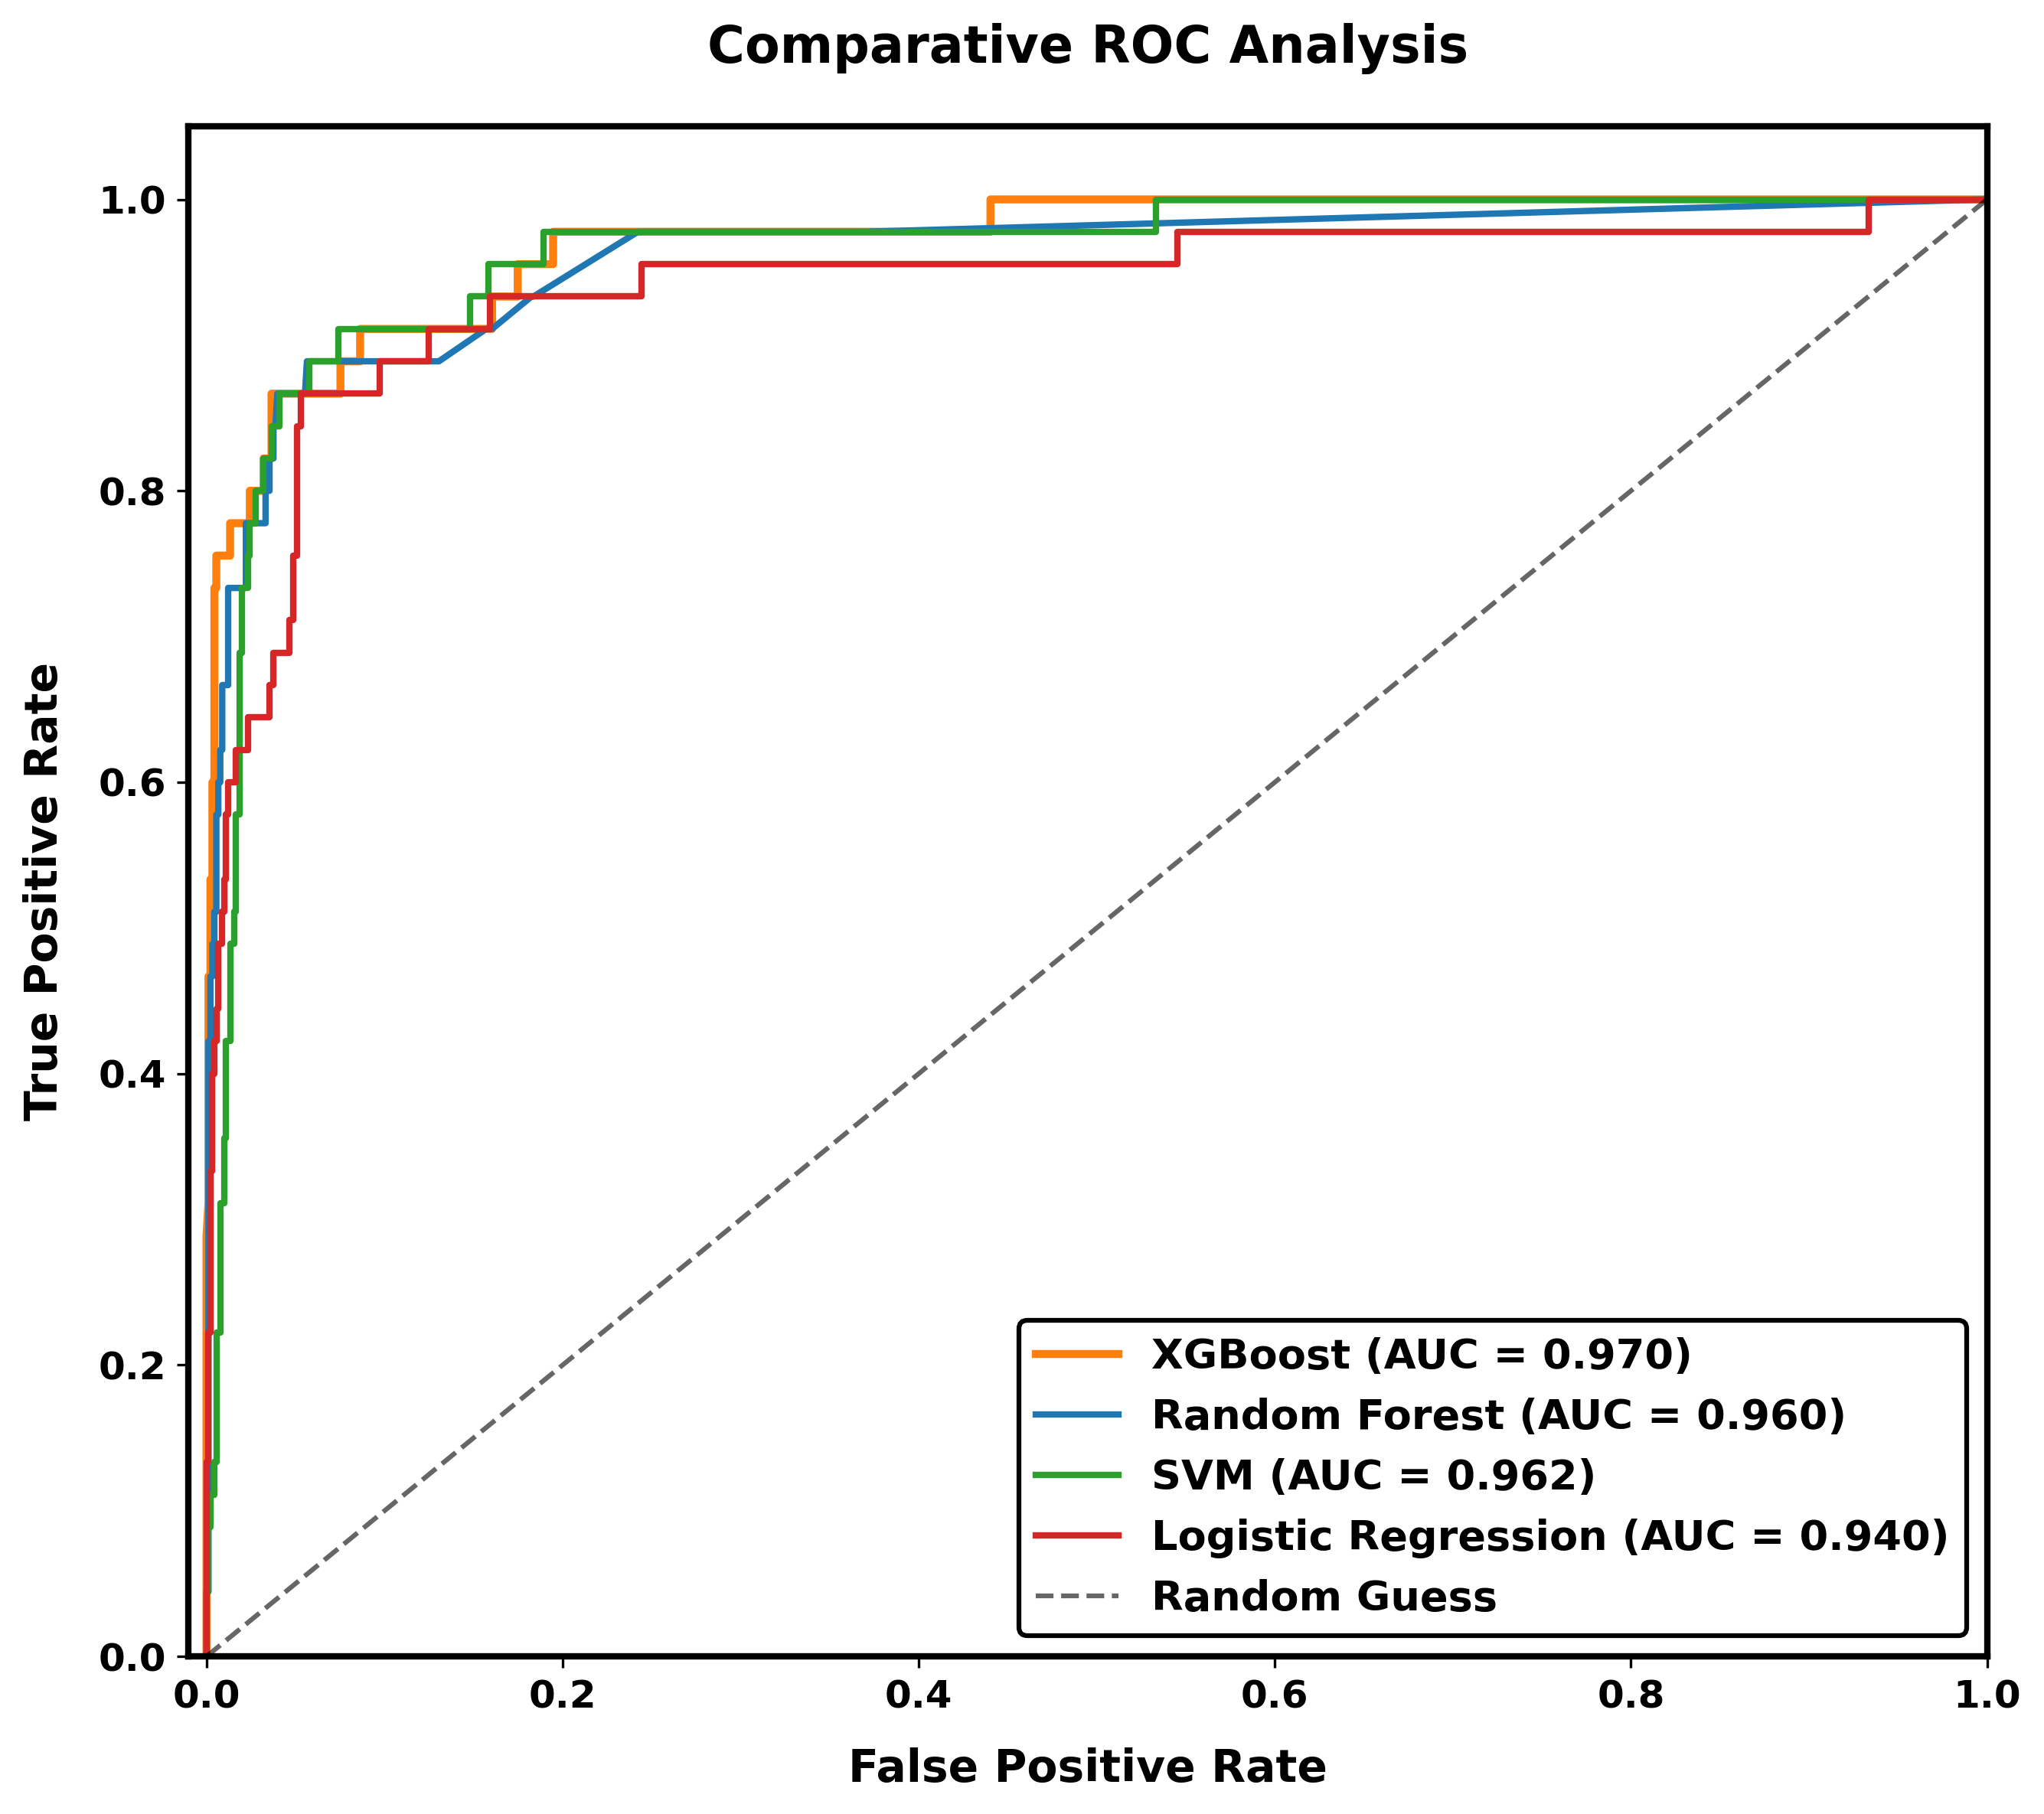

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate ROC metrics for all benchmarked models
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)
auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

# 2. Setup Plot Styling for Scientific Publication
plt.style.use('default') # This strips away the grid completely
plt.figure(figsize=(9, 8), dpi=300) # 300 DPI for the inline Colab preview

# Define colors for clarity
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# 3. Plot curves
plt.plot(fpr_xgb, tpr_xgb, color=colors[1], lw=2.5, label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot(fpr_rf, tpr_rf, color=colors[0], lw=2.0, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm, tpr_svm, color=colors[2], lw=2.0, label=f'SVM (AUC = {auc_svm:.3f})')
plt.plot(fpr_lr, tpr_lr, color=colors[3], lw=2.0, label=f'Logistic Regression (AUC = {auc_lr:.3f})')

# Plot Diagonal Reference
plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', alpha=0.6, label='Random Guess')

# 4. Final Formatting
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold', labelpad=10, color='black')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold', labelpad=10, color='black')
plt.title('Comparative ROC Analysis', fontsize=16, fontweight='bold', pad=20, color='black')

# Ensure tick marks are bold and clear
plt.xticks(fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=12, fontweight='bold', color='black')

# Apply Bold Black Border (Spines) around the entire plot
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(2.0)

# Configure Legend (Larger size, thick border, bold text)
legend = plt.legend(loc="lower right", frameon=True, fontsize=13, facecolor='white', framealpha=1)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_linewidth(1.5)

# Force every piece of text inside the legend to be bold and black
for text in legend.get_texts():
    text.set_fontweight('bold')
    text.set_color('black')

plt.tight_layout()

# 5. Export at 600 DPI for Journal Submission
# bbox_inches='tight' prevents the labels from being cut off in the saved image
plt.savefig('ROC_Curve_Publication_600DPI.png', dpi=600, bbox_inches='tight')
plt.show()

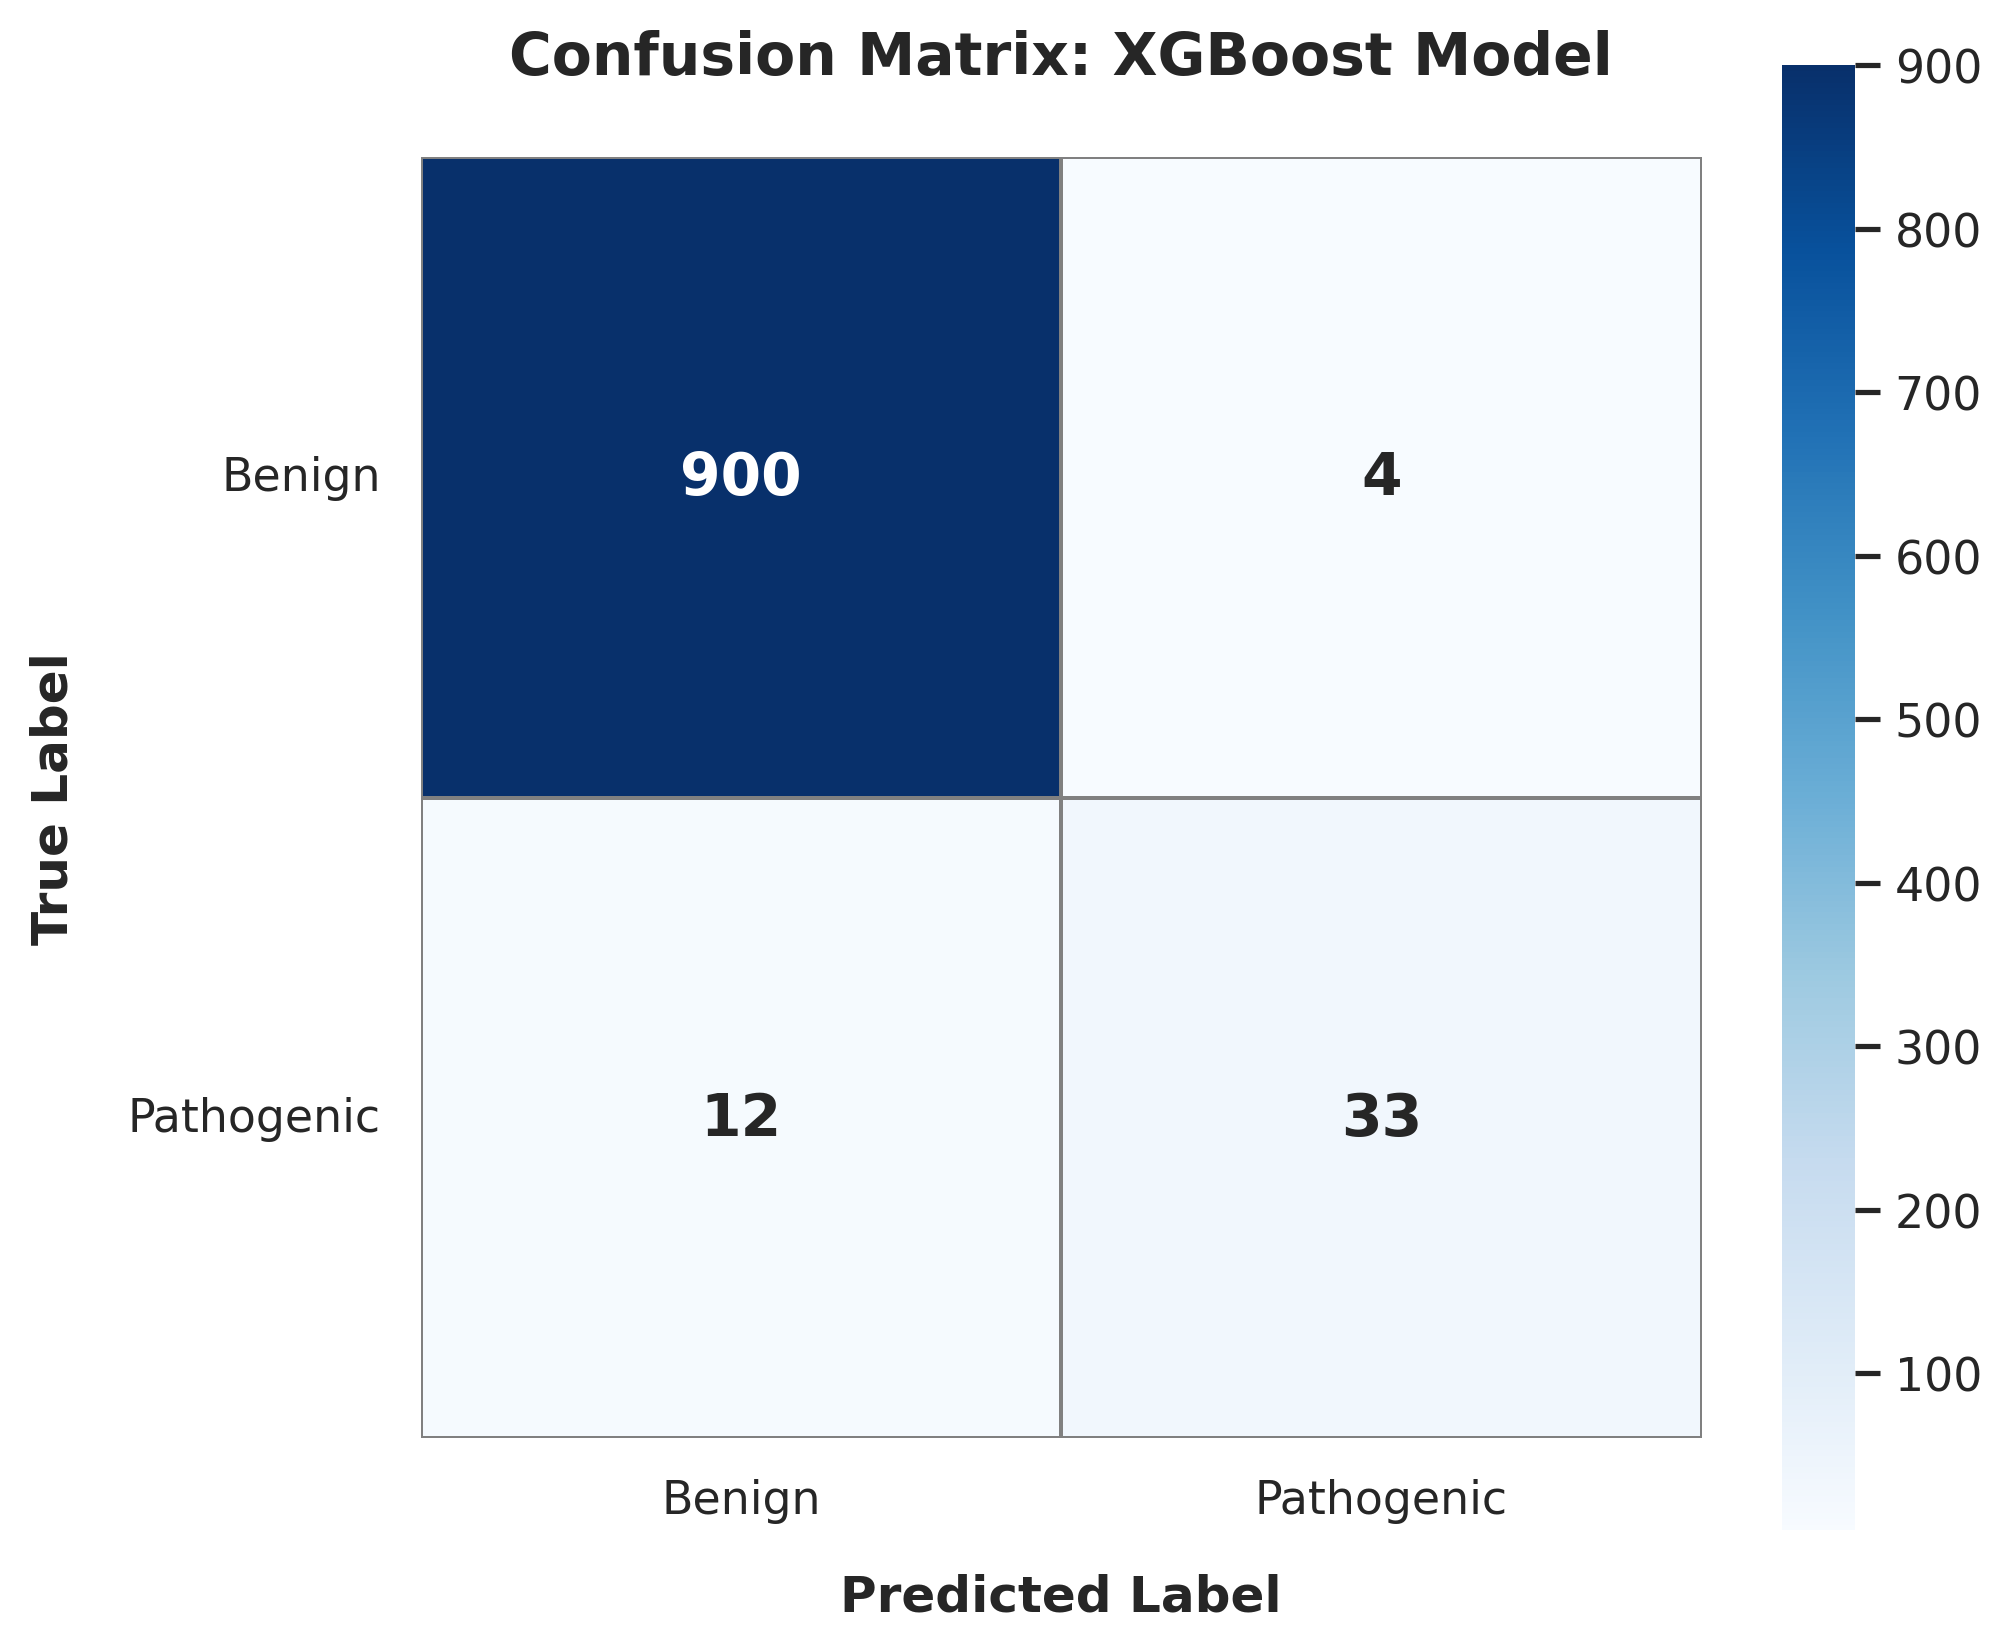

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the confusion matrix for the top performer (XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)

# 2. Setup the plot aesthetics for scientific publication
plt.figure(figsize=(7, 6), dpi=300)  # High DPI for publication quality
sns.set_theme(style='white')

# 3. Plot using a professional color palette (Blues is standard for journals)
ax = sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                 annot_kws={'size': 14, 'fontweight': 'bold'},
                 cbar=True, square=True, linewidths=0.5, linecolor='gray')

# 4. Refine labels and titles with bold font weights
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('Confusion Matrix: XGBoost Model', fontsize=14, fontweight='bold', pad=20)

# Map the labels for clarity (0: Benign, 1: Pathogenic)
ax.xaxis.set_ticklabels(['Benign', 'Pathogenic'], fontsize=11)
ax.yaxis.set_ticklabels(['Benign', 'Pathogenic'], fontsize=11, rotation=0, va='center')

plt.tight_layout()
plt.show()

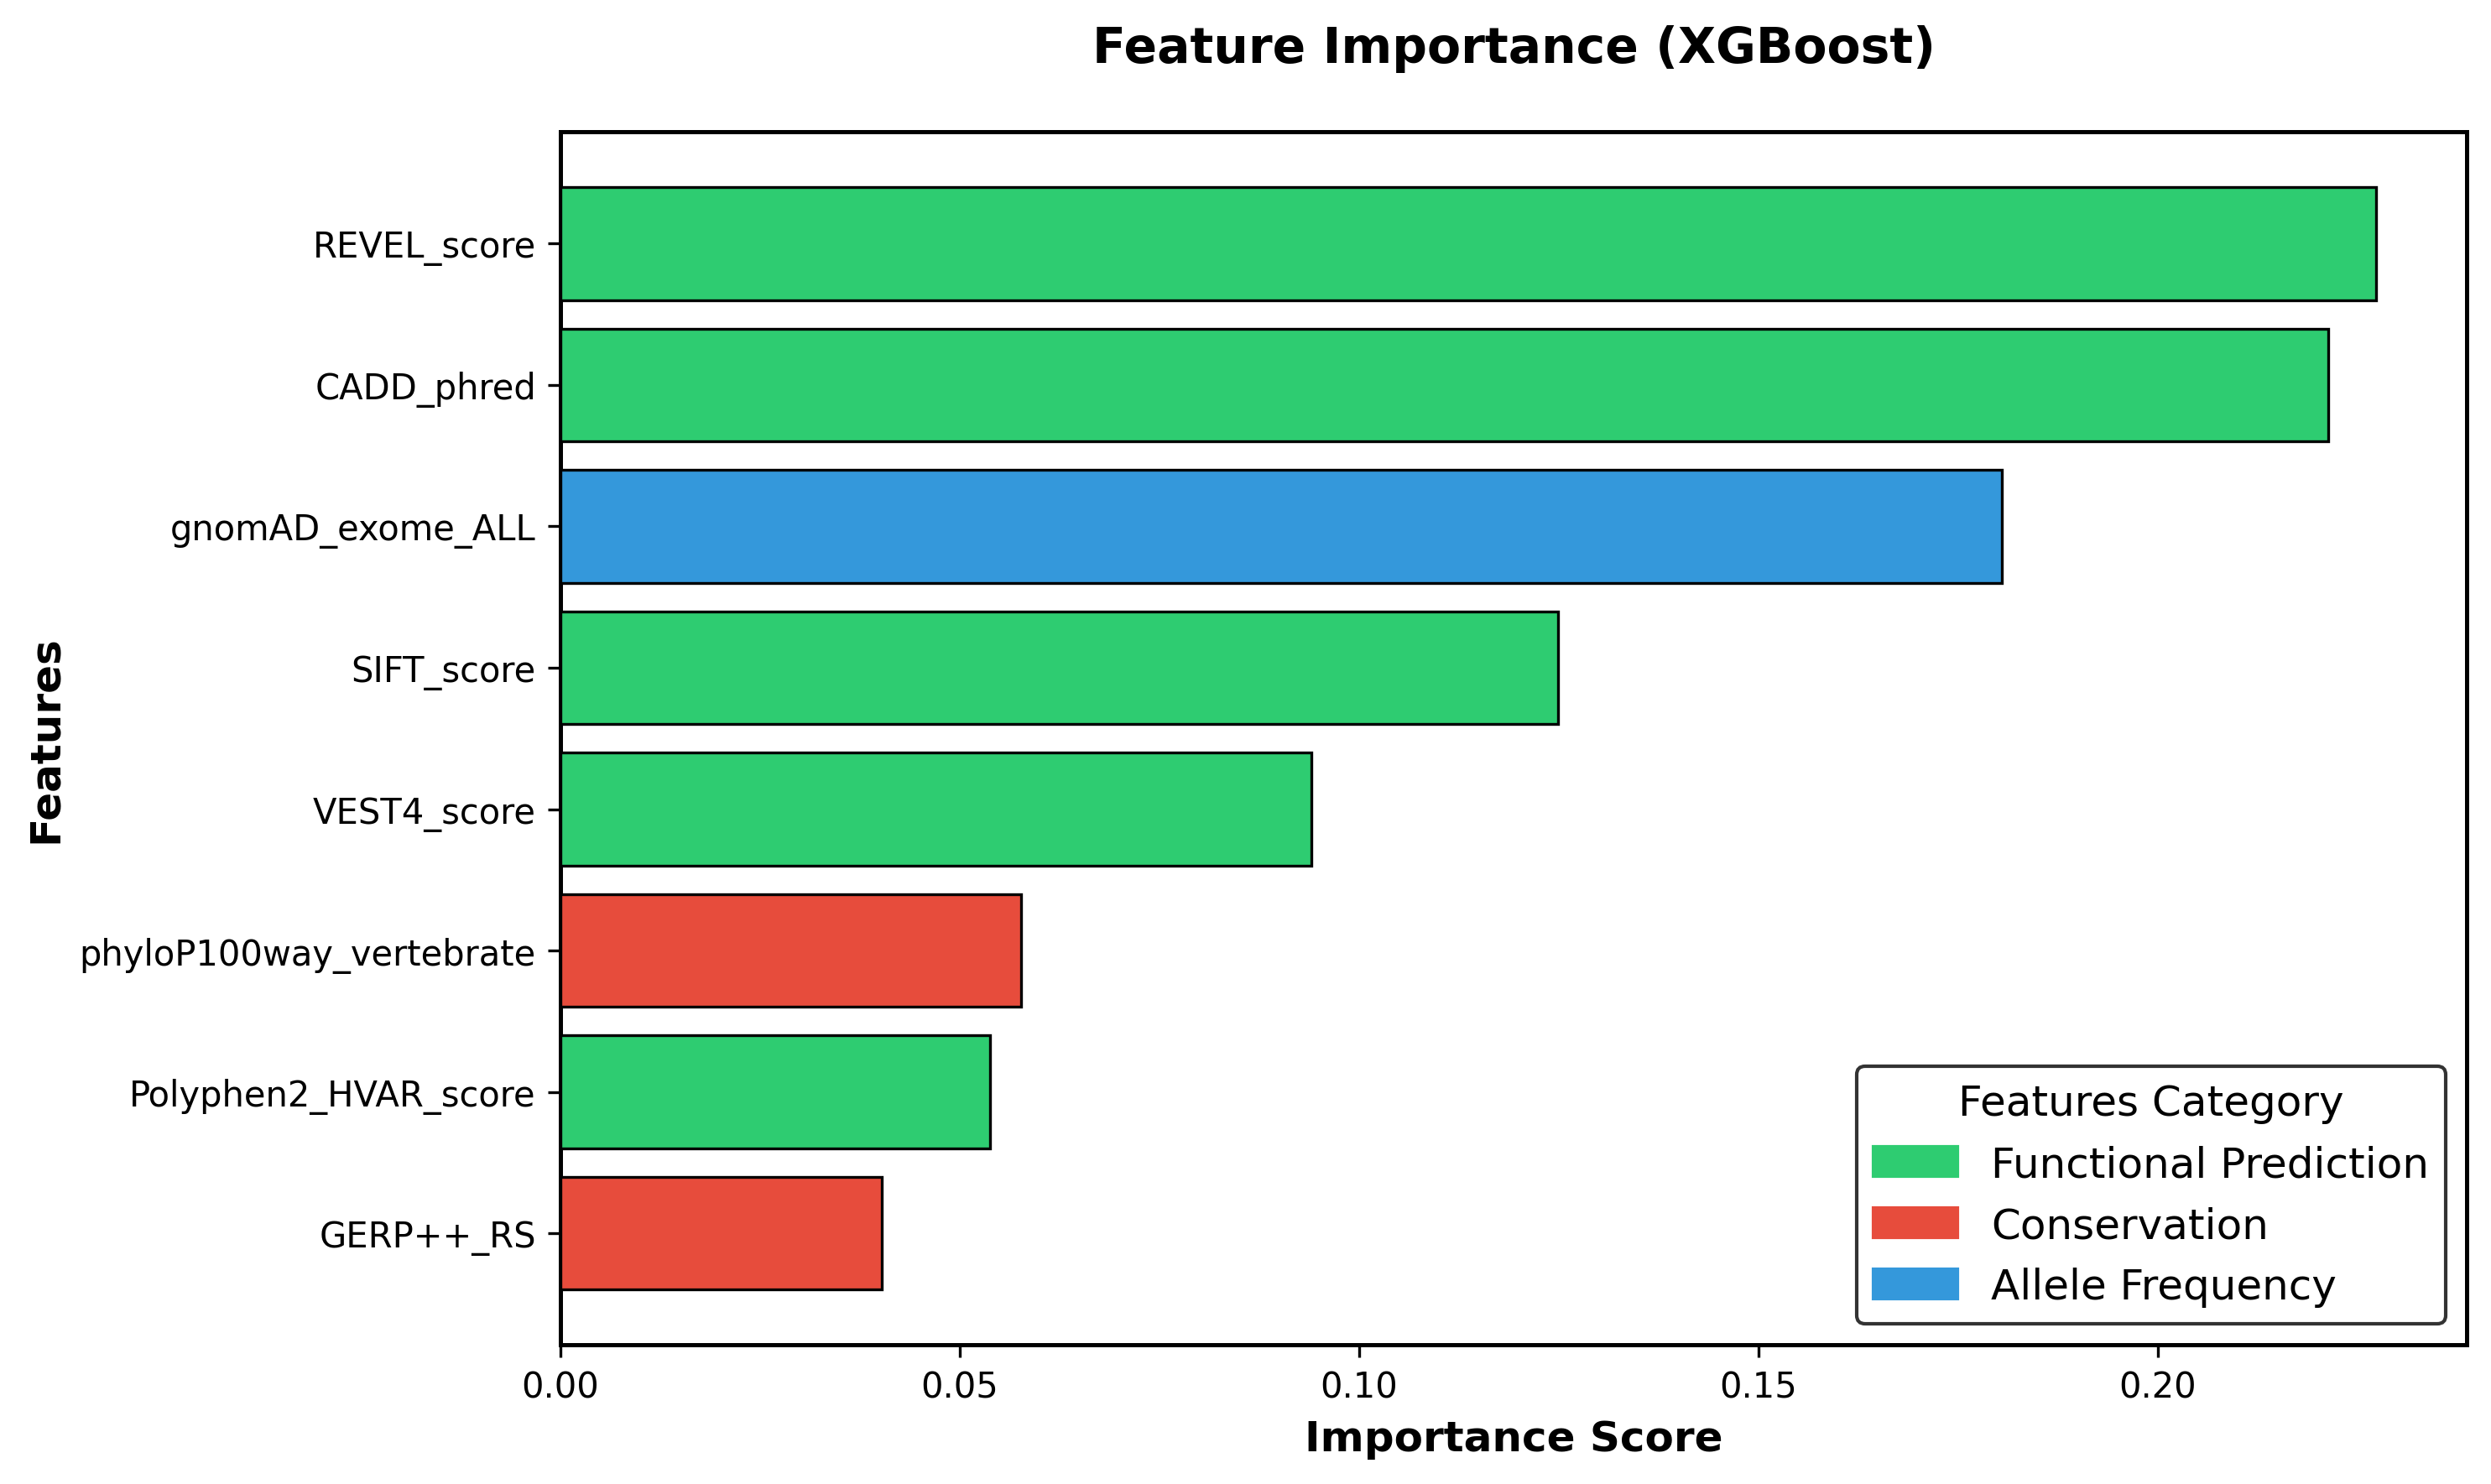

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.patches as mpatches

# 1. Define only the 8 intended genomic features
genomic_features = [
    "gnomAD_exome_ALL", "SIFT_score", "Polyphen2_HVAR_score",
    "CADD_phred", "REVEL_score", "VEST4_score",
    "phyloP100way_vertebrate", "GERP++_RS"
]

# 2. Extract and strictly align importances with the 8 features
importances = xgb_model.feature_importances_[:len(genomic_features)]

# Biological category mapping
category_map = {
    "gnomAD_exome_ALL": "Allele Frequency",
    "phyloP100way_vertebrate": "Conservation",
    "GERP++_RS": "Conservation",
    "SIFT_score": "Functional Prediction",
    "Polyphen2_HVAR_score": "Functional Prediction",
    "CADD_phred": "Functional Prediction",
    "REVEL_score": "Functional Prediction",
    "VEST4_score": "Functional Prediction"
}

# Prepare data for plotting
feat_imp_df = pd.DataFrame({'Feature': genomic_features, 'Importance': importances})
feat_imp_df['Category'] = feat_imp_df['Feature'].map(category_map)
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 3. Scientific Styling for Publication
plt.figure(figsize=(10, 6), dpi=300)
plt.style.use('default') # Ensures no grid is present

# Use professional categorical colors
colors_dict = {
    "Functional Prediction": "#2ecc71",
    "Conservation": "#e74c3c",
    "Allele Frequency": "#3498db"
}
bar_colors = [colors_dict[cat] for cat in feat_imp_df['Category']]

# Plotting
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
         color=bar_colors, edgecolor='black', linewidth=0.8, zorder=3)

# 4. Add Legend and Labels
legend_patches = [mpatches.Patch(color=color, label=label)
                  for label, color in colors_dict.items()]

# Legend size reduced slightly (size 12)
plt.legend(handles=legend_patches, title="Features Category",
           loc='lower right', frameon=True, edgecolor='black',
           prop={'size': 12}, title_fontsize=12)

plt.title('Feature Importance (XGBoost)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')

# Clean borders
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()

### 4. Hyperparameter Optimization
To maximize the model's ability to identify rare pathogenic variants, we perform a Grid Search on the XGBoost classifier, specifically adjusting `scale_pos_weight` to account for class imbalance.

### 4.1 Automated Tuning Strategy (Grid Search)
Instead of manual trial-and-error, we use `GridSearchCV` to systematically explore the XGBoost hyperparameter space.

**Key Parameters Optimized:**
*   `scale_pos_weight`: This is the most critical parameter for clinical datasets. By setting it to 10, we tell the model to treat each misclassified pathogenic variant as 10 times more 'costly' than a misclassified benign one, significantly boosting our clinical sensitivity (Recall).
*   `max_depth` & `learning_rate`: These control model complexity and the speed of learning to prevent overfitting.
*   `subsample` & `colsample_bytree`: These introduce randomness during training, which helps the model generalize better to unseen genomic data.

In [ ]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# 1. Define an optimized parameter grid
# Adding scale_pos_weight to handle the clear class imbalance (224 vs 4521)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, 10, 20] # Crucial for scientific datasets with rare events
}

# 2. Initialize GridSearchCV with ROC AUC scoring for overall diagnostic ability
grid = GridSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5, # Using 5-fold CV for more reliable estimates
    verbose=1,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
grid.fit(X_train, y_train)

# 3. Best Model Selection
print("\n--- Tuning Results ---")
print(f"Best Parameters: {grid.best_params_}")
best_xgb = grid.best_estimator_

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

--- Tuning Results ---
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200, 'scale_pos_weight': 10, 'subsample': 0.8}


In [ ]:
# 4. Re-evaluate on held-out test set
y_pred_tuned = best_xgb.predict(X_test)
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Final Model Evaluation (Tuned XGBoost) ---")
print(f"Tuned ROC-AUC: {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"Tuned F1 Score: {f1_score(y_test, y_pred_tuned):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Benign', 'Pathogenic']))


--- Final Model Evaluation (Tuned XGBoost) ---
Tuned ROC-AUC: 0.9618
Tuned F1 Score: 0.6441

Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.96      0.98       904
  Pathogenic       0.52      0.84      0.64        45

    accuracy                           0.96       949
   macro avg       0.76      0.90      0.81       949
weighted avg       0.97      0.96      0.96       949



### 4.2 Robust Validation of the Tuned Model
Following scientific standards, we perform a 5-fold stratified cross-validation on our final optimized XGBoost model to ensure the performance is consistent across different data subsets.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report
import numpy as np

# Initialize Stratified K-Fold Cross-Validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
accuracy_scores = []
roc_auc_scores = []
f1_scores = []
reports = []

print(f"Performing {n_splits}-fold cross-validation on the tuned XGBoost model...")

for fold, (train_index, test_index) in enumerate(skf.split(X_scaled, y)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    X_train_fold, X_test_fold = X_scaled[train_index], X_scaled[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Use the best_xgb estimator identified during tuning
    fold_model = best_xgb

    # Train the model on the current fold's training data
    fold_model.fit(X_train_fold, y_train_fold)

    # Make predictions and calculate probabilities
    y_pred_fold = fold_model.predict(X_test_fold)
    y_prob_fold = fold_model.predict_proba(X_test_fold)[:, 1]

    # Evaluate metrics
    acc = accuracy_score(y_test_fold, y_pred_fold)
    roc_auc = roc_auc_score(y_test_fold, y_prob_fold)
    f1 = f1_score(y_test_fold, y_pred_fold)
    report = classification_report(y_test_fold, y_pred_fold, target_names=['Benign', 'Pathogenic'], output_dict=True)

    accuracy_scores.append(acc)
    roc_auc_scores.append(roc_auc)
    f1_scores.append(f1)
    reports.append(report)

    print(f"Accuracy: {acc:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"F1 Score: {f1:.4f}")

print("\n--- Cross-Validation Results Summary ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average ROC AUC: {np.mean(roc_auc_scores):.4f} (+/- {np.std(roc_auc_scores):.4f})")
print(f"Average F1 Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

# Average classification report details for the critical 'Pathogenic' class
avg_recall_pathogenic = np.mean([r['Pathogenic']['recall'] for r in reports])
avg_precision_pathogenic = np.mean([r['Pathogenic']['precision'] for r in reports])
avg_f1_pathogenic = np.mean([r['Pathogenic']['f1-score'] for r in reports])

print("\nAverage Pathogenic Class Metrics across all folds:")
print(f"  Recall: {avg_recall_pathogenic:.4f}")
print(f"  Precision: {avg_precision_pathogenic:.4f}")
print(f"  F1-Score: {avg_f1_pathogenic:.4f}")

Performing 5-fold cross-validation on the tuned XGBoost model...

--- Fold 1/5 ---
Accuracy: 0.9663
ROC AUC: 0.9802
F1 Score: 0.6800

--- Fold 2/5 ---
Accuracy: 0.9600
ROC AUC: 0.9494
F1 Score: 0.6545

--- Fold 3/5 ---
Accuracy: 0.9652
ROC AUC: 0.9715
F1 Score: 0.7080

--- Fold 4/5 ---
Accuracy: 0.9705
ROC AUC: 0.9779
F1 Score: 0.7143

--- Fold 5/5 ---
Accuracy: 0.9579
ROC AUC: 0.9828
F1 Score: 0.6610

--- Cross-Validation Results Summary ---
Average Accuracy: 0.9640 (+/- 0.0045)
Average ROC AUC: 0.9724 (+/- 0.0121)
Average F1 Score: 0.6836 (+/- 0.0241)

Average Pathogenic Class Metrics across all folds:
  Recall: 0.8212
  Precision: 0.5888
  F1-Score: 0.6836


### 5. Final Model Comparison
We compare the performance of the 'off-the-shelf' XGBoost model against our tuned version to visualize the improvement in recall for the pathogenic class.

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report

# 1. Capture reports as dictionaries for direct comparison
report_orig = classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Pathogenic'], output_dict=True)
report_tuned = classification_report(y_test, y_pred_tuned, target_names=['Benign', 'Pathogenic'], output_dict=True)

# 2. Extract key metrics for Pathogenic class (Label 1)
comparison_data = {
    'Metric': ['Recall (Pathogenic)', 'Precision (Pathogenic)', 'F1-Score (Pathogenic)', 'Overall Accuracy', 'ROC AUC'],
    'Original XGBoost': [
        report_orig['Pathogenic']['recall'],
        report_orig['Pathogenic']['precision'],
        report_orig['Pathogenic']['f1-score'],
        report_orig['accuracy'],
        auc_xgb
    ],
    'Tuned XGBoost (scale_pos_weight=10)': [
        report_tuned['Pathogenic']['recall'],
        report_tuned['Pathogenic']['precision'],
        report_tuned['Pathogenic']['f1-score'],
        report_tuned['accuracy'],
        roc_auc_score(y_test, y_prob_tuned)
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))

,Metric,Original XGBoost,Tuned XGBoost (scale_pos_weight=10)
0,Recall (Pathogenic),0.7333,0.8444
1,Precision (Pathogenic),0.8919,0.5205
2,F1-Score (Pathogenic),0.8049,0.6441
3,Overall Accuracy,0.9831,0.9557
4,ROC AUC,0.9704,0.9618


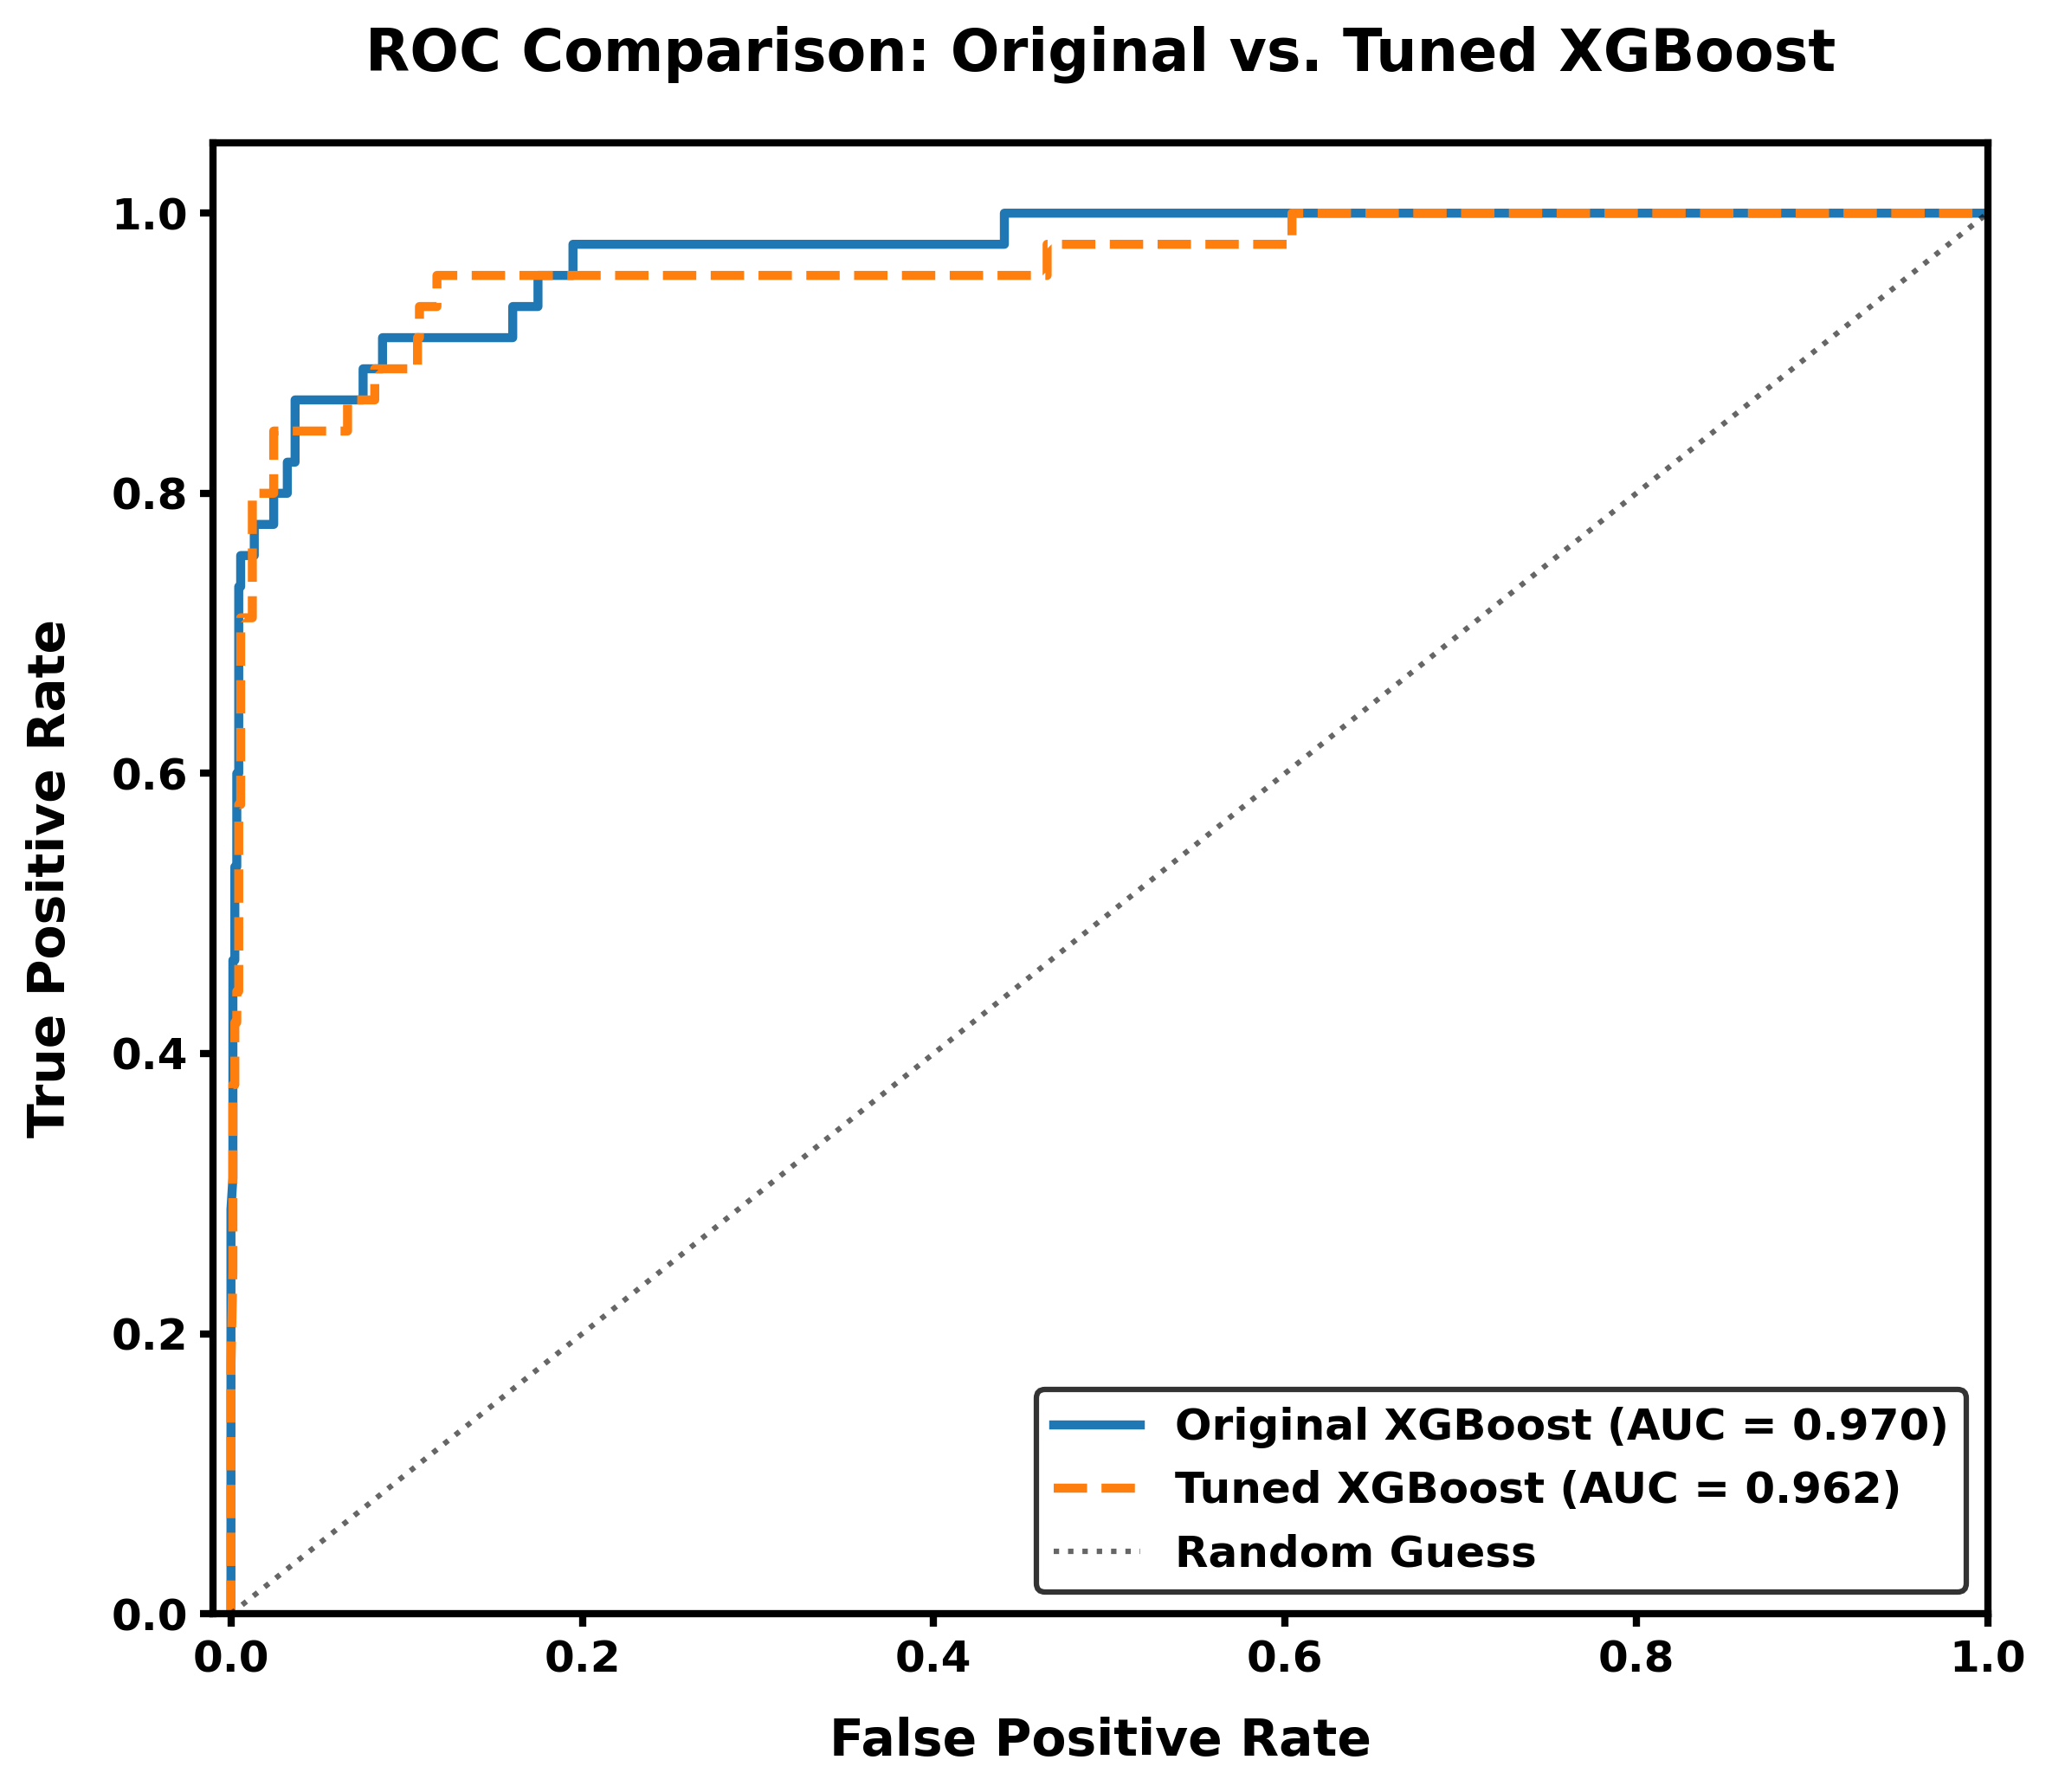

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate ROC metrics
fpr_orig, tpr_orig, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_orig = auc(fpr_orig, tpr_orig)

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
roc_auc_tuned = auc(fpr_tuned, tpr_tuned)

# 2. Setup Scientific Plot Styling
plt.style.use('default') # Ensures no grid is present
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# 3. Plot both curves
ax.plot(fpr_orig, tpr_orig, color='#1f77b4', lw=2.5,
         label=f'Original XGBoost (AUC = {roc_auc_orig:.3f})')

ax.plot(fpr_tuned, tpr_tuned, color='#ff7f0e', lw=2.5, linestyle='--',
         label=f'Tuned XGBoost (AUC = {roc_auc_tuned:.3f})')

# Plot Diagonal Reference
ax.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle=':', alpha=0.6, label='Random Guess')

# 4. Final Formatting - Bold, Black, and Clear
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold', color='black', labelpad=10)
ax.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold', color='black', labelpad=10)
ax.set_title('ROC Comparison: Original vs. Tuned XGBoost', fontsize=16, fontweight='bold', color='black', pad=20)

# Apply Bold Black Spines
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_edgecolor('black')

# Bold Tick Labels
ax.tick_params(axis='both', which='major', labelsize=12, colors='black', width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# 5. Scientific Legend
legend = ax.legend(loc="lower right", frameon=True, fontsize=12, edgecolor='black')
legend.get_frame().set_linewidth(1.5)
for text in legend.get_texts():
    text.set_fontweight('bold')
    text.set_color('black')

plt.tight_layout()
plt.show()

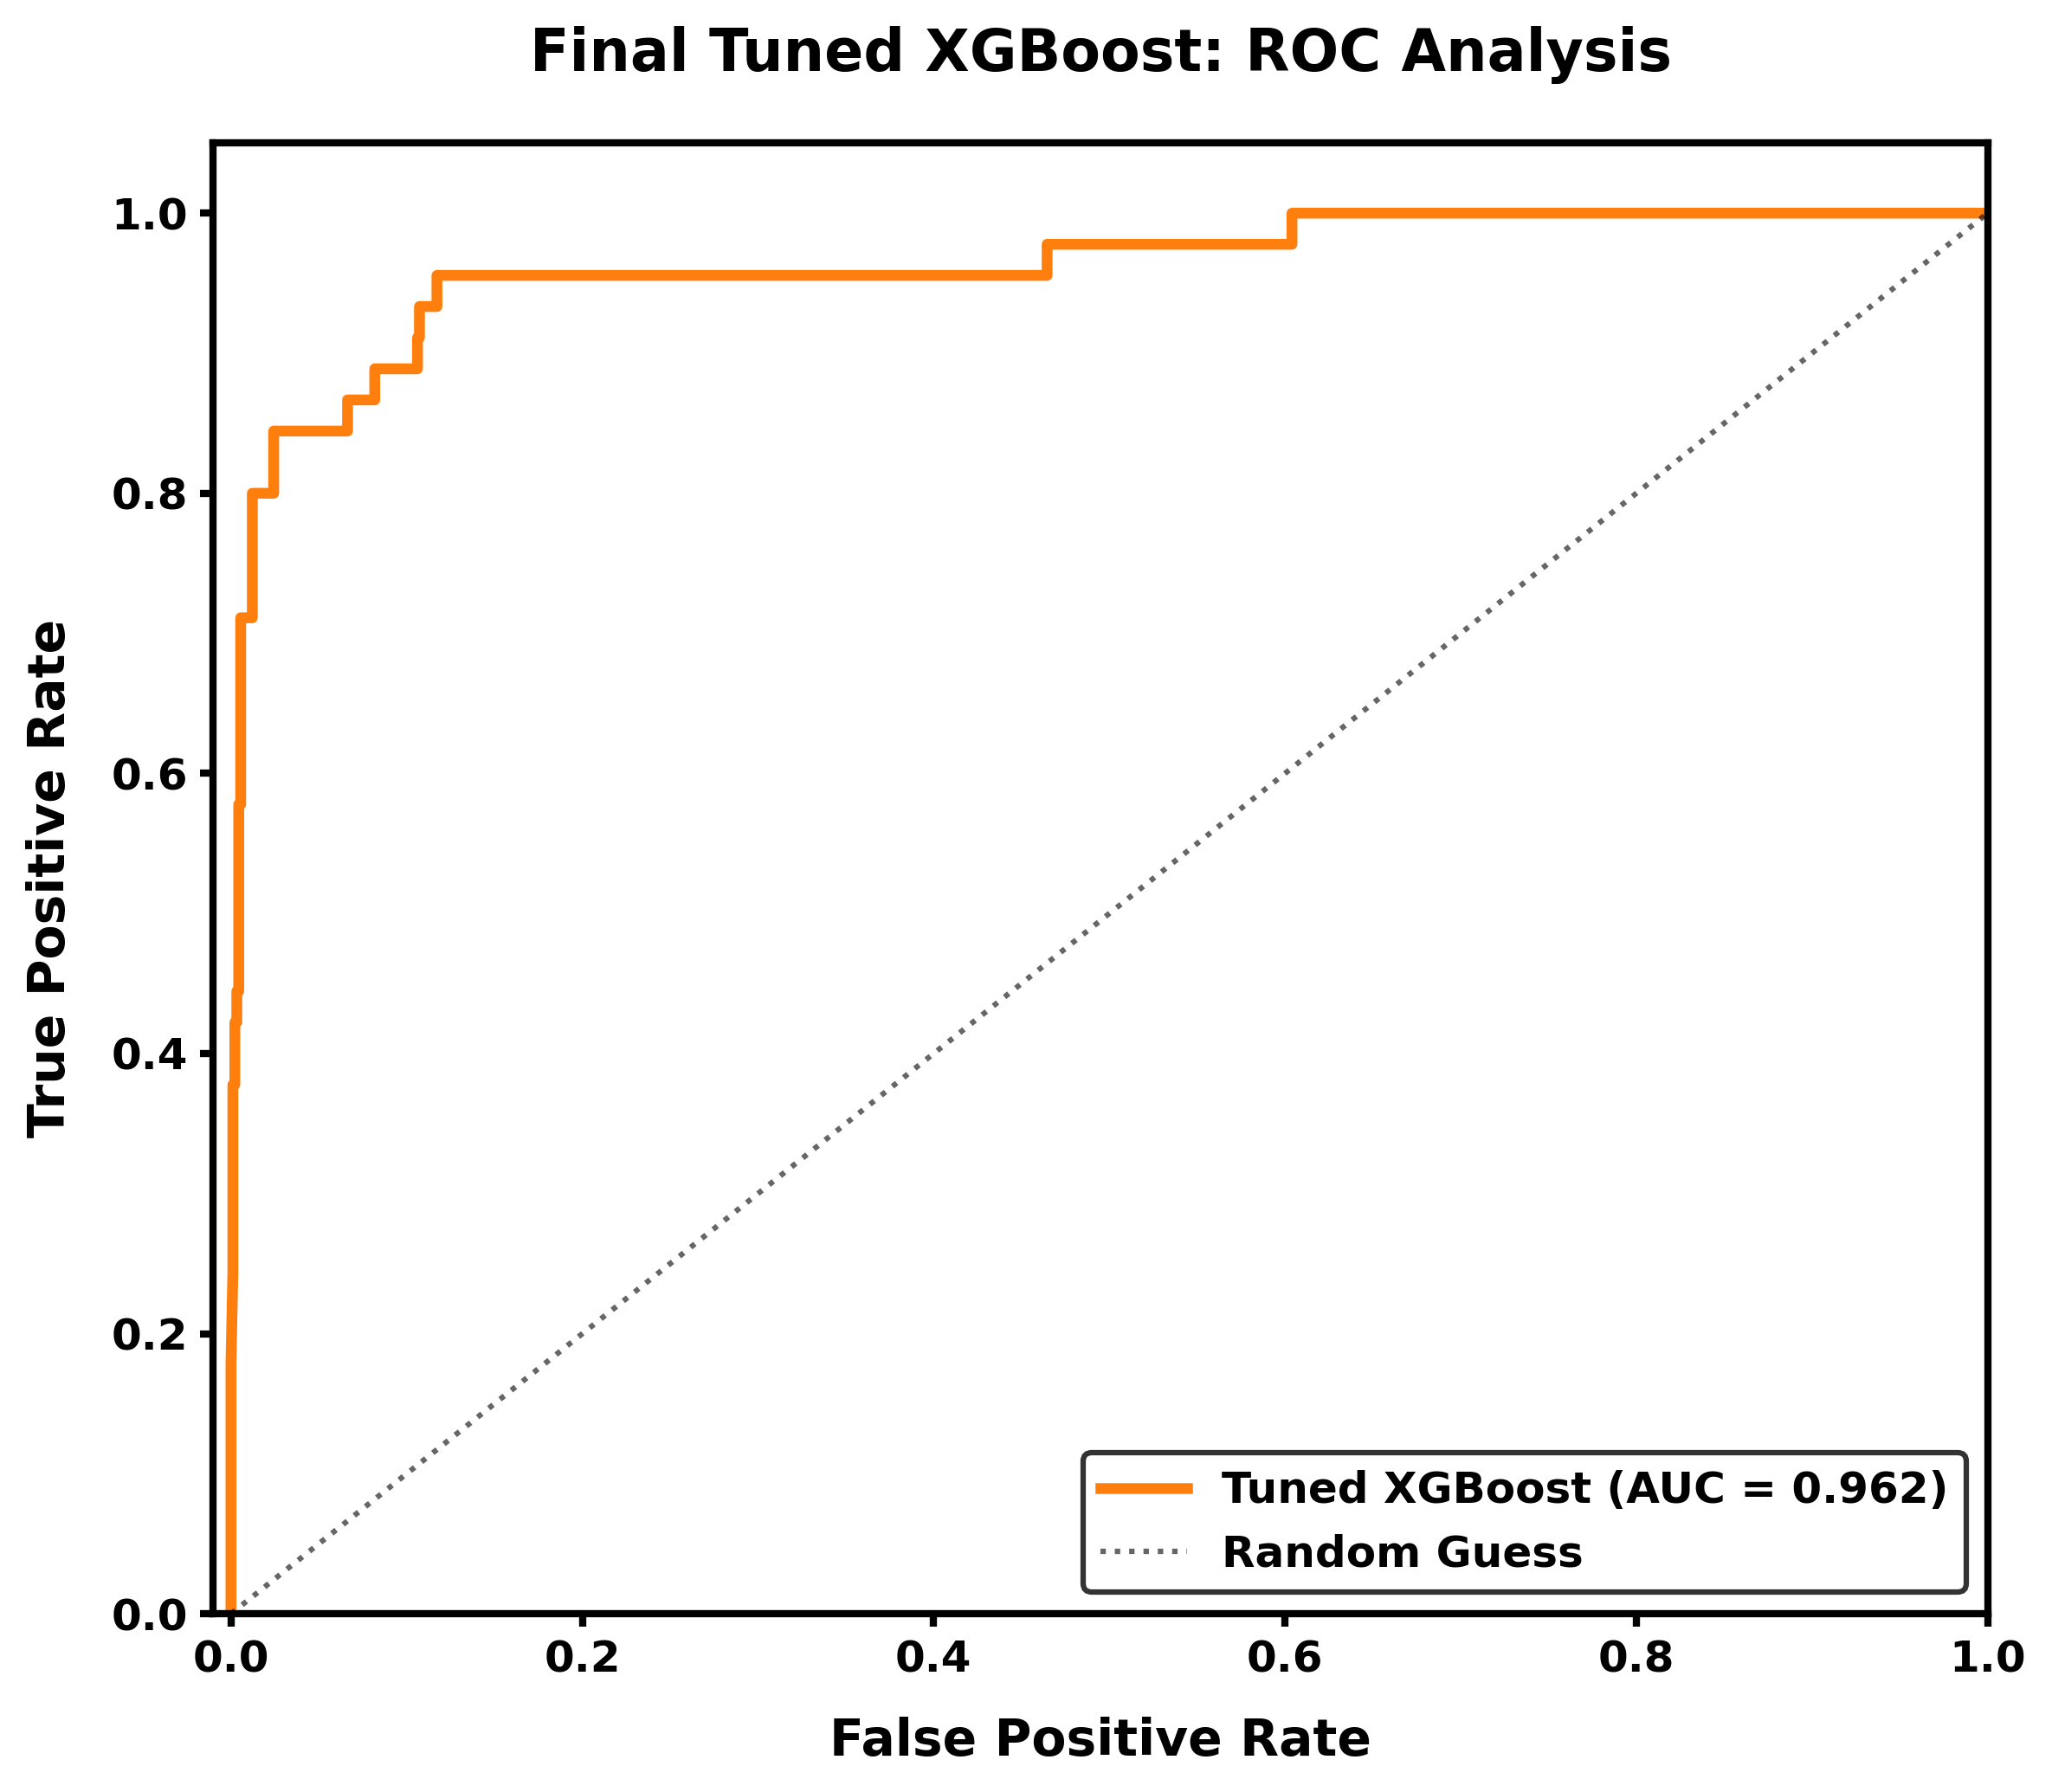

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Calculate ROC metrics for the tuned XGBoost
fpr_t, tpr_t, _ = roc_curve(y_test, y_prob_tuned)
roc_auc_t = auc(fpr_t, tpr_t)

# 2. Setup Scientific Plot Styling for Publication
plt.style.use('default')
fig, ax = plt.subplots(figsize=(8, 7), dpi=300)

# 3. Plotting the ROC curve
ax.plot(fpr_t, tpr_t, color='#ff7f0e', lw=3.0,
         label=f'Tuned XGBoost (AUC = {roc_auc_t:.3f})')

# Plotting the diagonal baseline
ax.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle=':', alpha=0.6, label='Random Guess')

# 4. Final Formatting - Bold, Black, and Clear
ax.set_xlim([-0.01, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=14, fontweight='bold', color='black', labelpad=10)
ax.set_ylabel('True Positive Rate', fontsize=14, fontweight='bold', color='black', labelpad=10)
ax.set_title('Final Tuned XGBoost: ROC Analysis', fontsize=16, fontweight='bold', color='black', pad=20)

# Apply Bold Black Spines (Linewidth 2.0)
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
    spine.set_edgecolor('black')

# Bold Tick Labels
ax.tick_params(axis='both', which='major', labelsize=12, colors='black', width=2)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# 5. Scientific Legend with Solid Black Frame
legend = ax.legend(loc="lower right", frameon=True, fontsize=12, edgecolor='black')
legend.get_frame().set_linewidth(1.5)
for text in legend.get_texts():
    text.set_fontweight('bold')
    text.set_color('black')

plt.tight_layout()
plt.show()

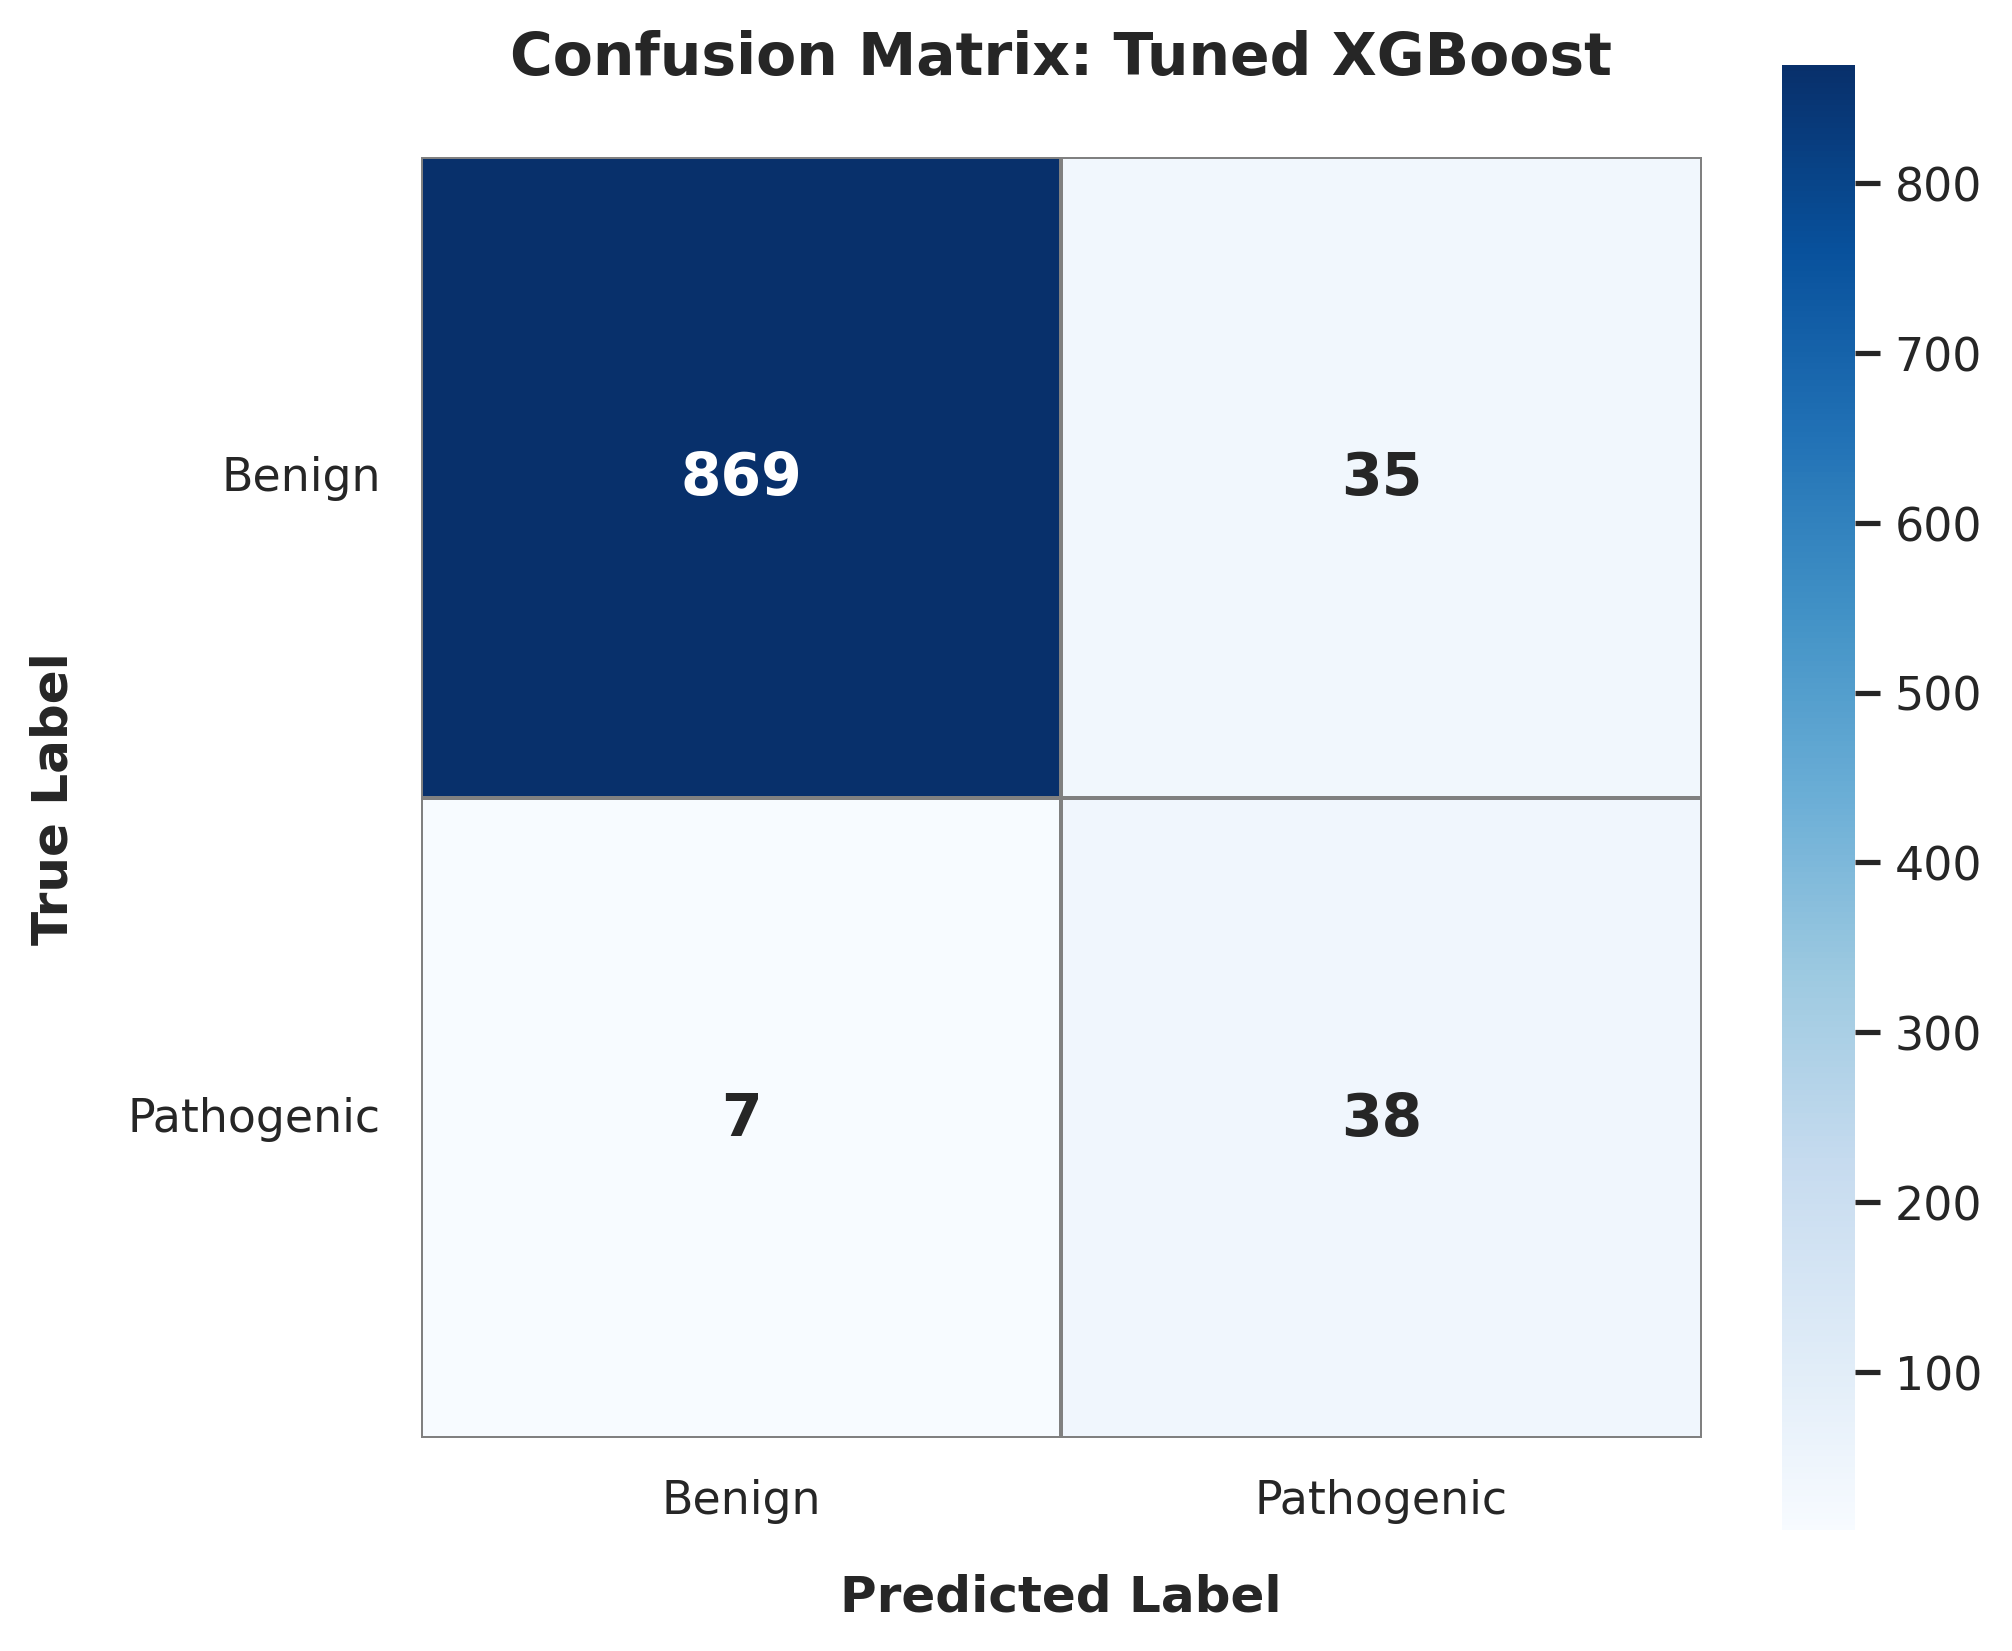

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Generate the confusion matrix for the Tuned XGBoost
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# 2. Setup the plot aesthetics
plt.figure(figsize=(7, 6), dpi=300)
sns.set_theme(style='white')

# 3. Plot using the Blues colormap
ax = sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues',
                 annot_kws={'size': 14, 'fontweight': 'bold'},
                 cbar=True, square=True, linewidths=0.5, linecolor='gray')

# 4. Refine labels
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold', labelpad=12)
ax.set_ylabel('True Label', fontsize=12, fontweight='bold', labelpad=12)
ax.set_title('Confusion Matrix: Tuned XGBoost', fontsize=14, fontweight='bold', pad=20)

ax.xaxis.set_ticklabels(['Benign', 'Pathogenic'], fontsize=11)
ax.yaxis.set_ticklabels(['Benign', 'Pathogenic'], fontsize=11, rotation=0, va='center')

plt.tight_layout()
plt.show()

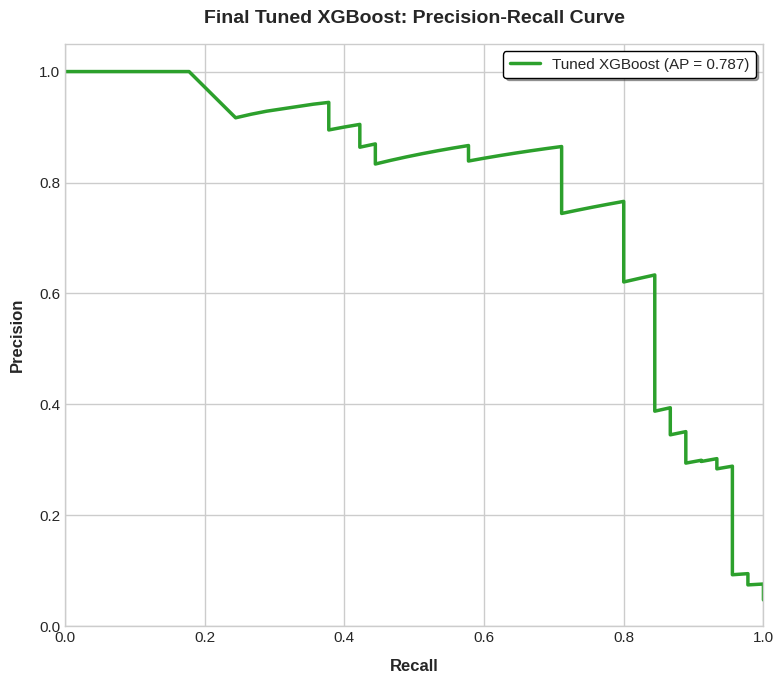

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Calculate Precision-Recall metrics
precision, recall, _ = precision_recall_curve(y_test, y_prob_tuned)
ap_score = average_precision_score(y_test, y_prob_tuned)

# 2. Setup Plot Styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(8, 7), dpi=100)

# 3. Plot the curve
plt.plot(recall, precision, color='#2ca02c', lw=2.5,
         label=f'Tuned XGBoost (AP = {ap_score:.3f})')

# 4. Formatting axes
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Precision', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Final Tuned XGBoost: Precision-Recall Curve', fontsize=14, fontweight='bold', pad=15)

plt.legend(loc="upper right", frameon=True, fontsize=11, shadow=True, edgecolor='black')
plt.tight_layout()
plt.show()

### 1. Categorized Feature Importance (Built-in XGBoost)
We begin by visualizing which features the XGBoost model relied on most during training, grouped by their biological utility.

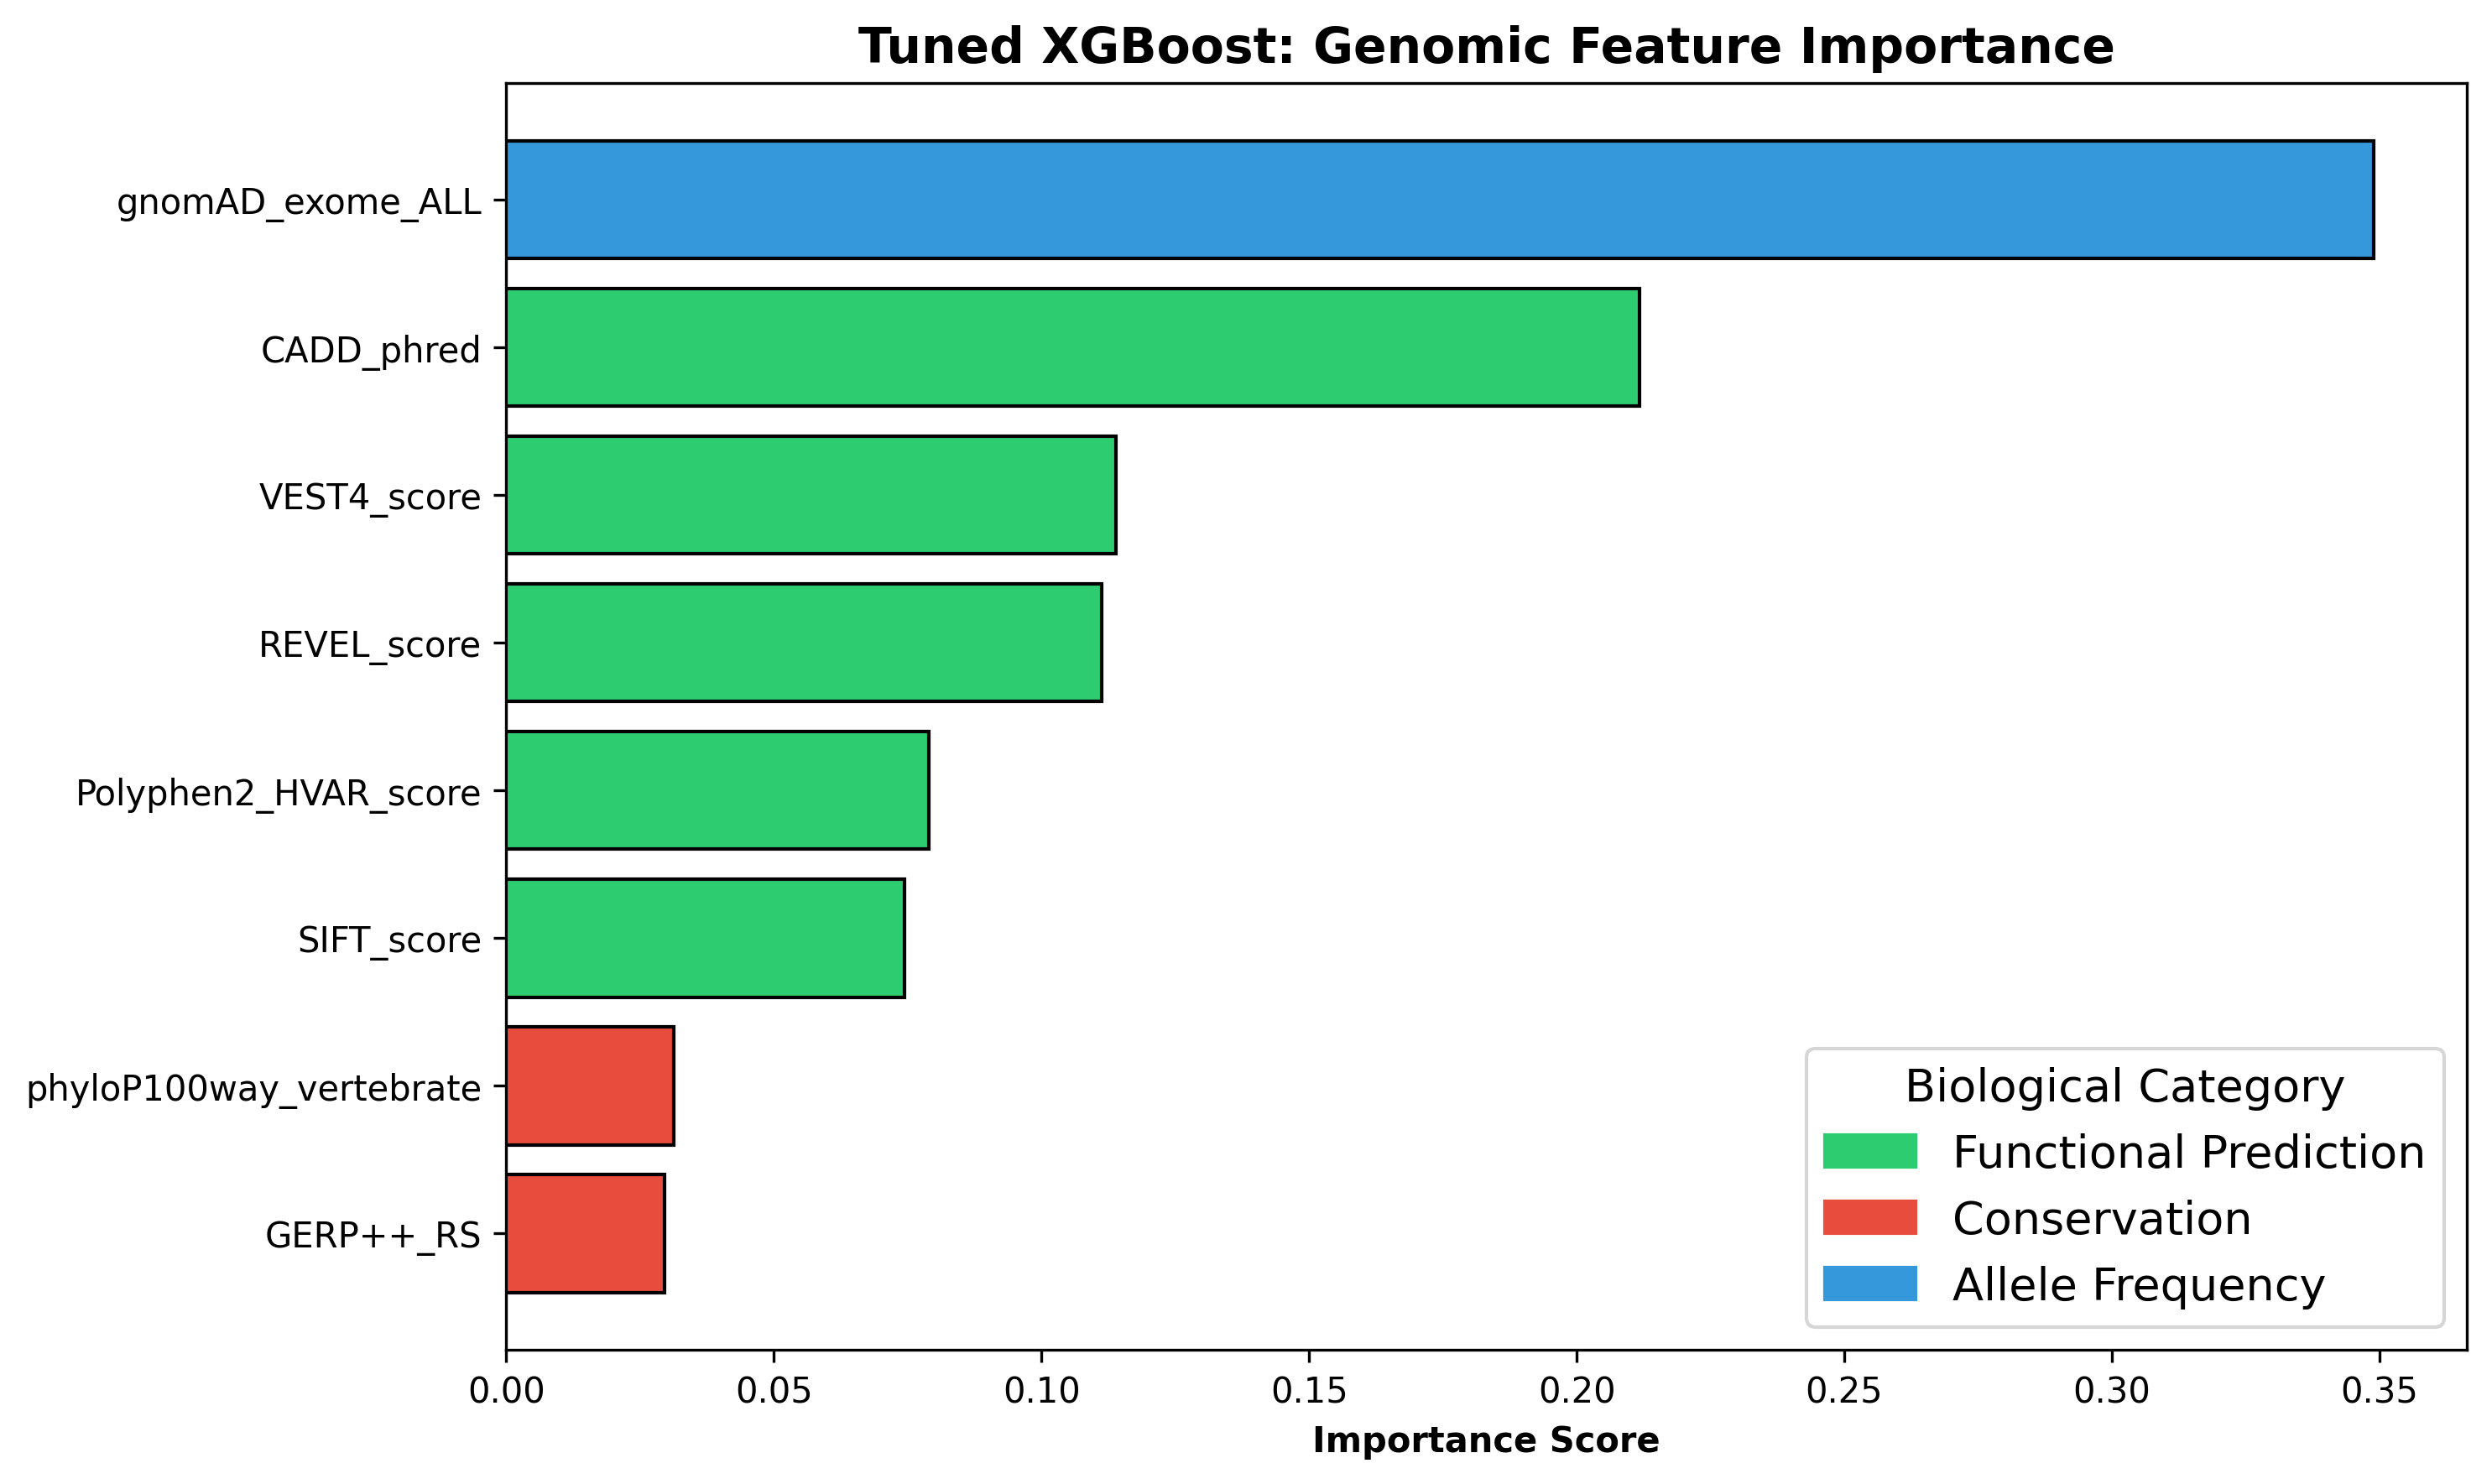

In [ ]:
import matplotlib.patches as mpatches

# 1. Align features and importances
importances_tuned = best_xgb.feature_importances_

# 2. Categorization for biological context
category_map = {
    'gnomAD_exome_ALL': 'Allele Frequency',
    'phyloP100way_vertebrate': 'Conservation',
    'GERP++_RS': 'Conservation',
    'SIFT_score': 'Functional Prediction',
    'Polyphen2_HVAR_score': 'Functional Prediction',
    'CADD_phred': 'Functional Prediction',
    'REVEL_score': 'Functional Prediction',
    'VEST4_score': 'Functional Prediction'
}

feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances_tuned})
feat_imp_df['Category'] = feat_imp_df['Feature'].map(category_map)
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=True)

# 3. Plotting - Enhanced to 300 DPI for scientific publication
plt.figure(figsize=(10, 6), dpi=300)
colors_dict = {'Functional Prediction': '#2ecc71', 'Conservation': '#e74c3c', 'Allele Frequency': '#3498db'}
bar_colors = [colors_dict[cat] for cat in feat_imp_df['Category']]

# No grid lines per request
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=bar_colors, edgecolor='black', zorder=3)

# 4. Legend - slightly increased font size
legend_patches = [mpatches.Patch(color=c, label=l) for l, c in colors_dict.items()]
plt.legend(handles=legend_patches, title="Biological Category", loc='lower right', frameon=True, prop={'size': 13}, title_fontsize=13)

plt.title('Tuned XGBoost: Genomic Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontweight='bold')
plt.tight_layout()
plt.show()

### 2. SHAP Model Explainability
While feature importance shows *which* features matter, SHAP shows *how* they matter (direction and magnitude).

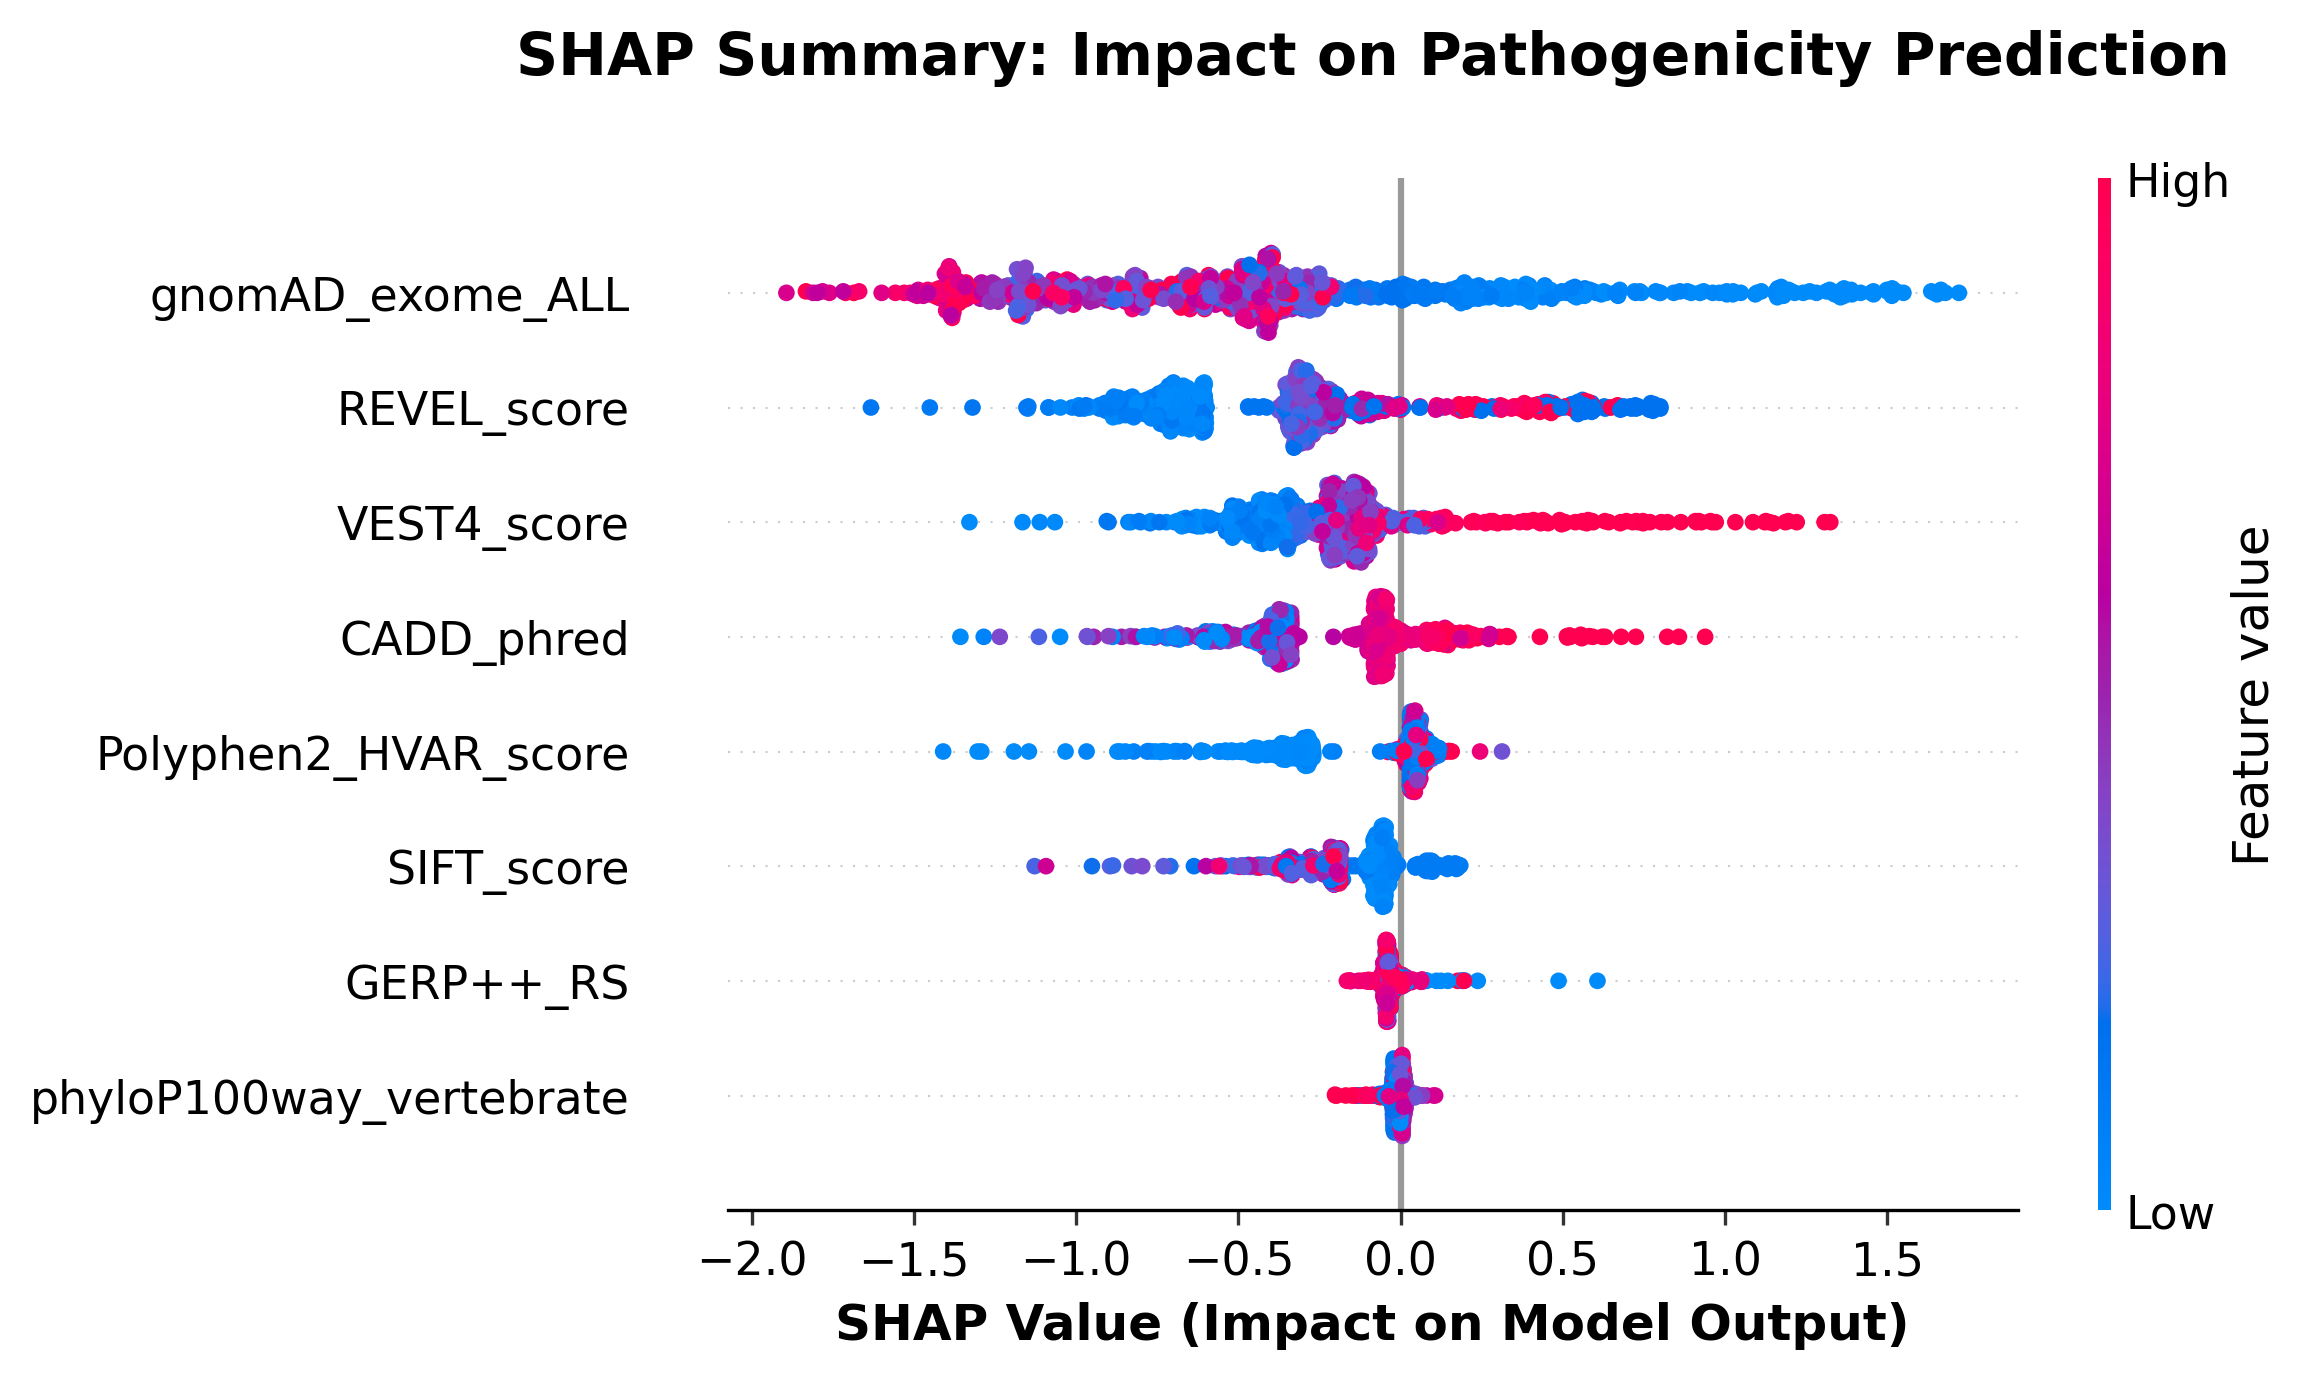

In [ ]:
!pip install shap
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# 2. SHAP Summary (Beeswarm) Plot with Scientific Styling
plt.style.use('default')
plt.figure(figsize=(10, 6), dpi=300)

# Adding a bold title
plt.title('SHAP Summary: Impact on Pathogenicity Prediction', fontsize=14, fontweight='bold', pad=25, color='black')

# Generate the summary plot
# Note: shap.summary_plot handles its own axes but we can pass show=False to refine with matplotlib
shap.summary_plot(shap_values, X_test, feature_names=features, show=False)

# Refine axis labels and ticks to be bold black for consistency
ax = plt.gca()
ax.set_xlabel('SHAP Value (Impact on Model Output)', fontsize=12, fontweight='bold', color='black')
plt.xticks(fontsize=11, color='black')
plt.yticks(fontsize=11, color='black')

plt.tight_layout()
plt.show()

### 3. SHAP Dependence Plots
We will examine the top 3 features to see the specific thresholds where the model begins to classify variants as pathogenic.

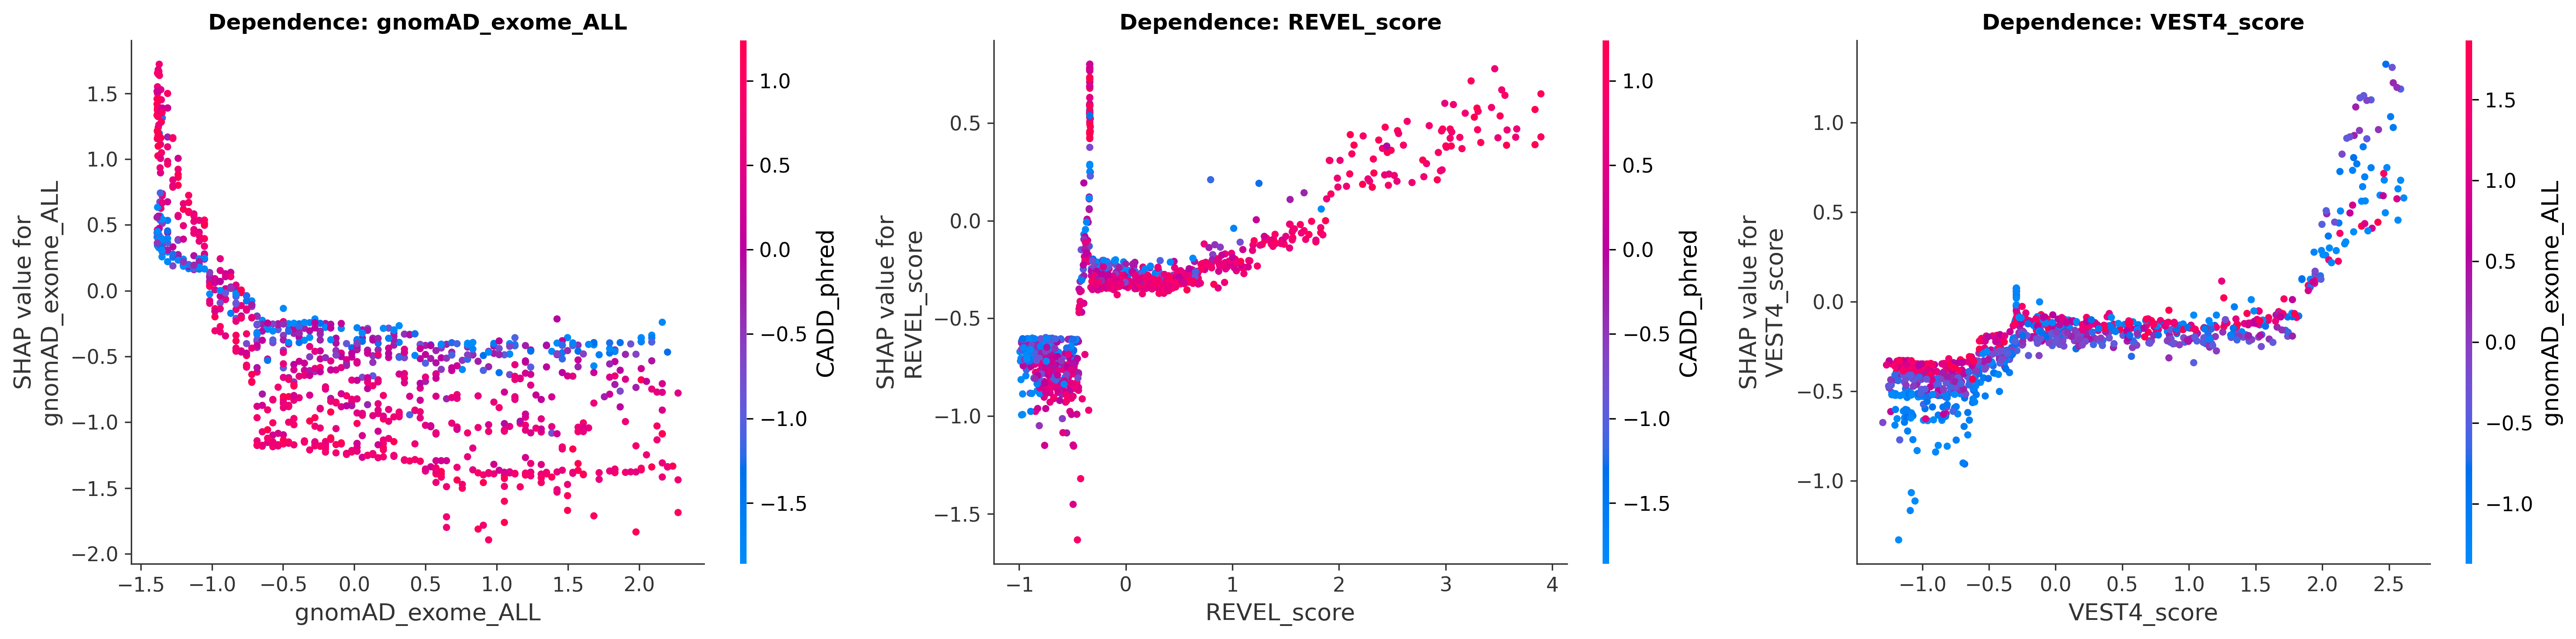

In [ ]:
# Identify top 3 features from SHAP values
vals = np.abs(shap_values).mean(0)
feature_importance_shap = pd.DataFrame(list(zip(features, vals)), columns=['col_name','feature_importance_vals'])
feature_importance_shap.sort_values(by=['feature_importance_vals'], ascending=False, inplace=True)
top_3_features = feature_importance_shap['col_name'].head(3).tolist()

# Create subplots for dependence
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=300)

for i, feat in enumerate(top_3_features):
    plt.sca(axes[i])
    # Convert X_test back to DF for plotting if it was an array
    X_test_df = pd.DataFrame(X_test, columns=features)
    shap.dependence_plot(feat, shap_values, X_test_df, ax=axes[i], show=False)
    axes[i].set_title(f'Dependence: {feat}', fontweight='bold')

plt.tight_layout()
plt.show()

### 4. Calibration Curve (Reliability Analysis)
This plot evaluates how well the probabilistic outputs of our Tuned XGBoost align with real-world frequencies. A well-calibrated model stays close to the diagonal line.

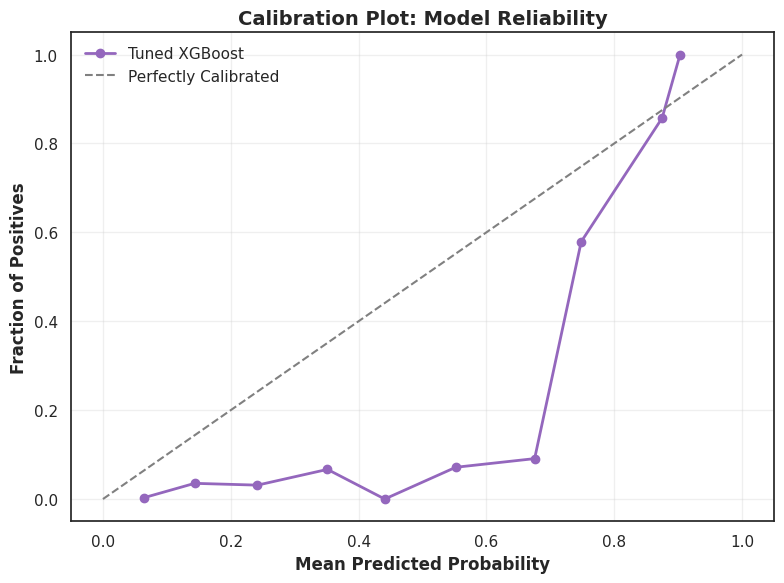

In [ ]:
from sklearn.calibration import calibration_curve

# 1. Calculate calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_tuned, n_bins=10)

# 2. Plotting
plt.figure(figsize=(8, 6), dpi=100)
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Tuned XGBoost', color='#9467bd')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')

plt.xlabel('Mean Predicted Probability', fontweight='bold')
plt.ylabel('Fraction of Positives', fontweight='bold')
plt.title('Calibration Plot: Model Reliability', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5. SHAP Interaction Plot
To see how the relationship between a score (like REVEL) and pathogenicity changes depending on another feature (like Allele Frequency), we can visualize the interaction effects.

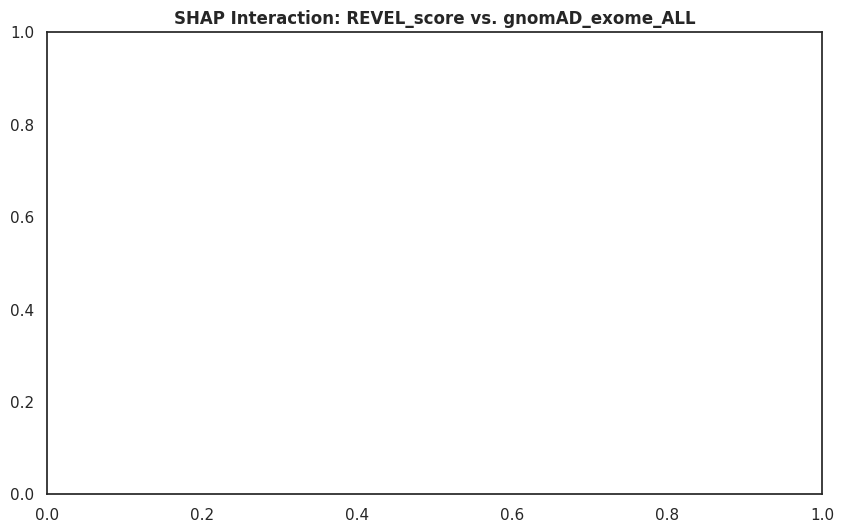

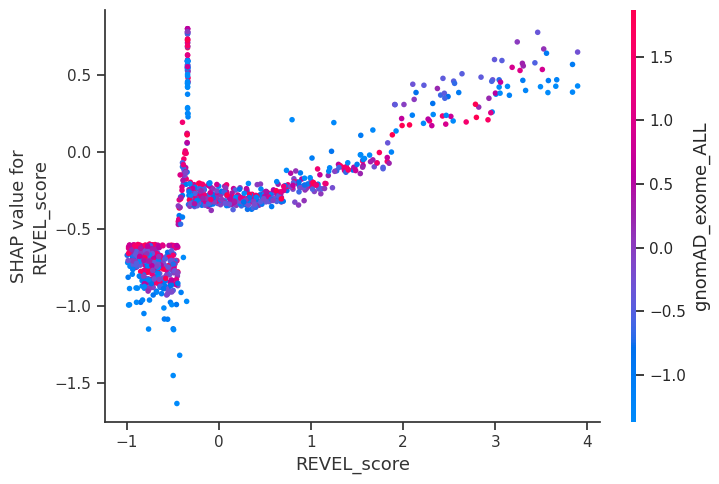

In [ ]:
# Visualizing interaction between the two most important features
# Note: This uses X_test_df which was defined in the previous SHAP cell
plt.figure(figsize=(10, 6))
plt.title('SHAP Interaction: REVEL_score vs. gnomAD_exome_ALL', fontsize=12, fontweight='bold')
shap.dependence_plot(
    "REVEL_score",
    shap_values,
    X_test_df,
    interaction_index="gnomAD_exome_ALL",
    show=False
)
plt.tight_layout()
plt.show()

### 6. Feature Correlation Analysis
Understanding how our input features correlate helps in assessing redundancy (e.g., between different functional prediction scores) and understanding the underlying structure of our genomic data.

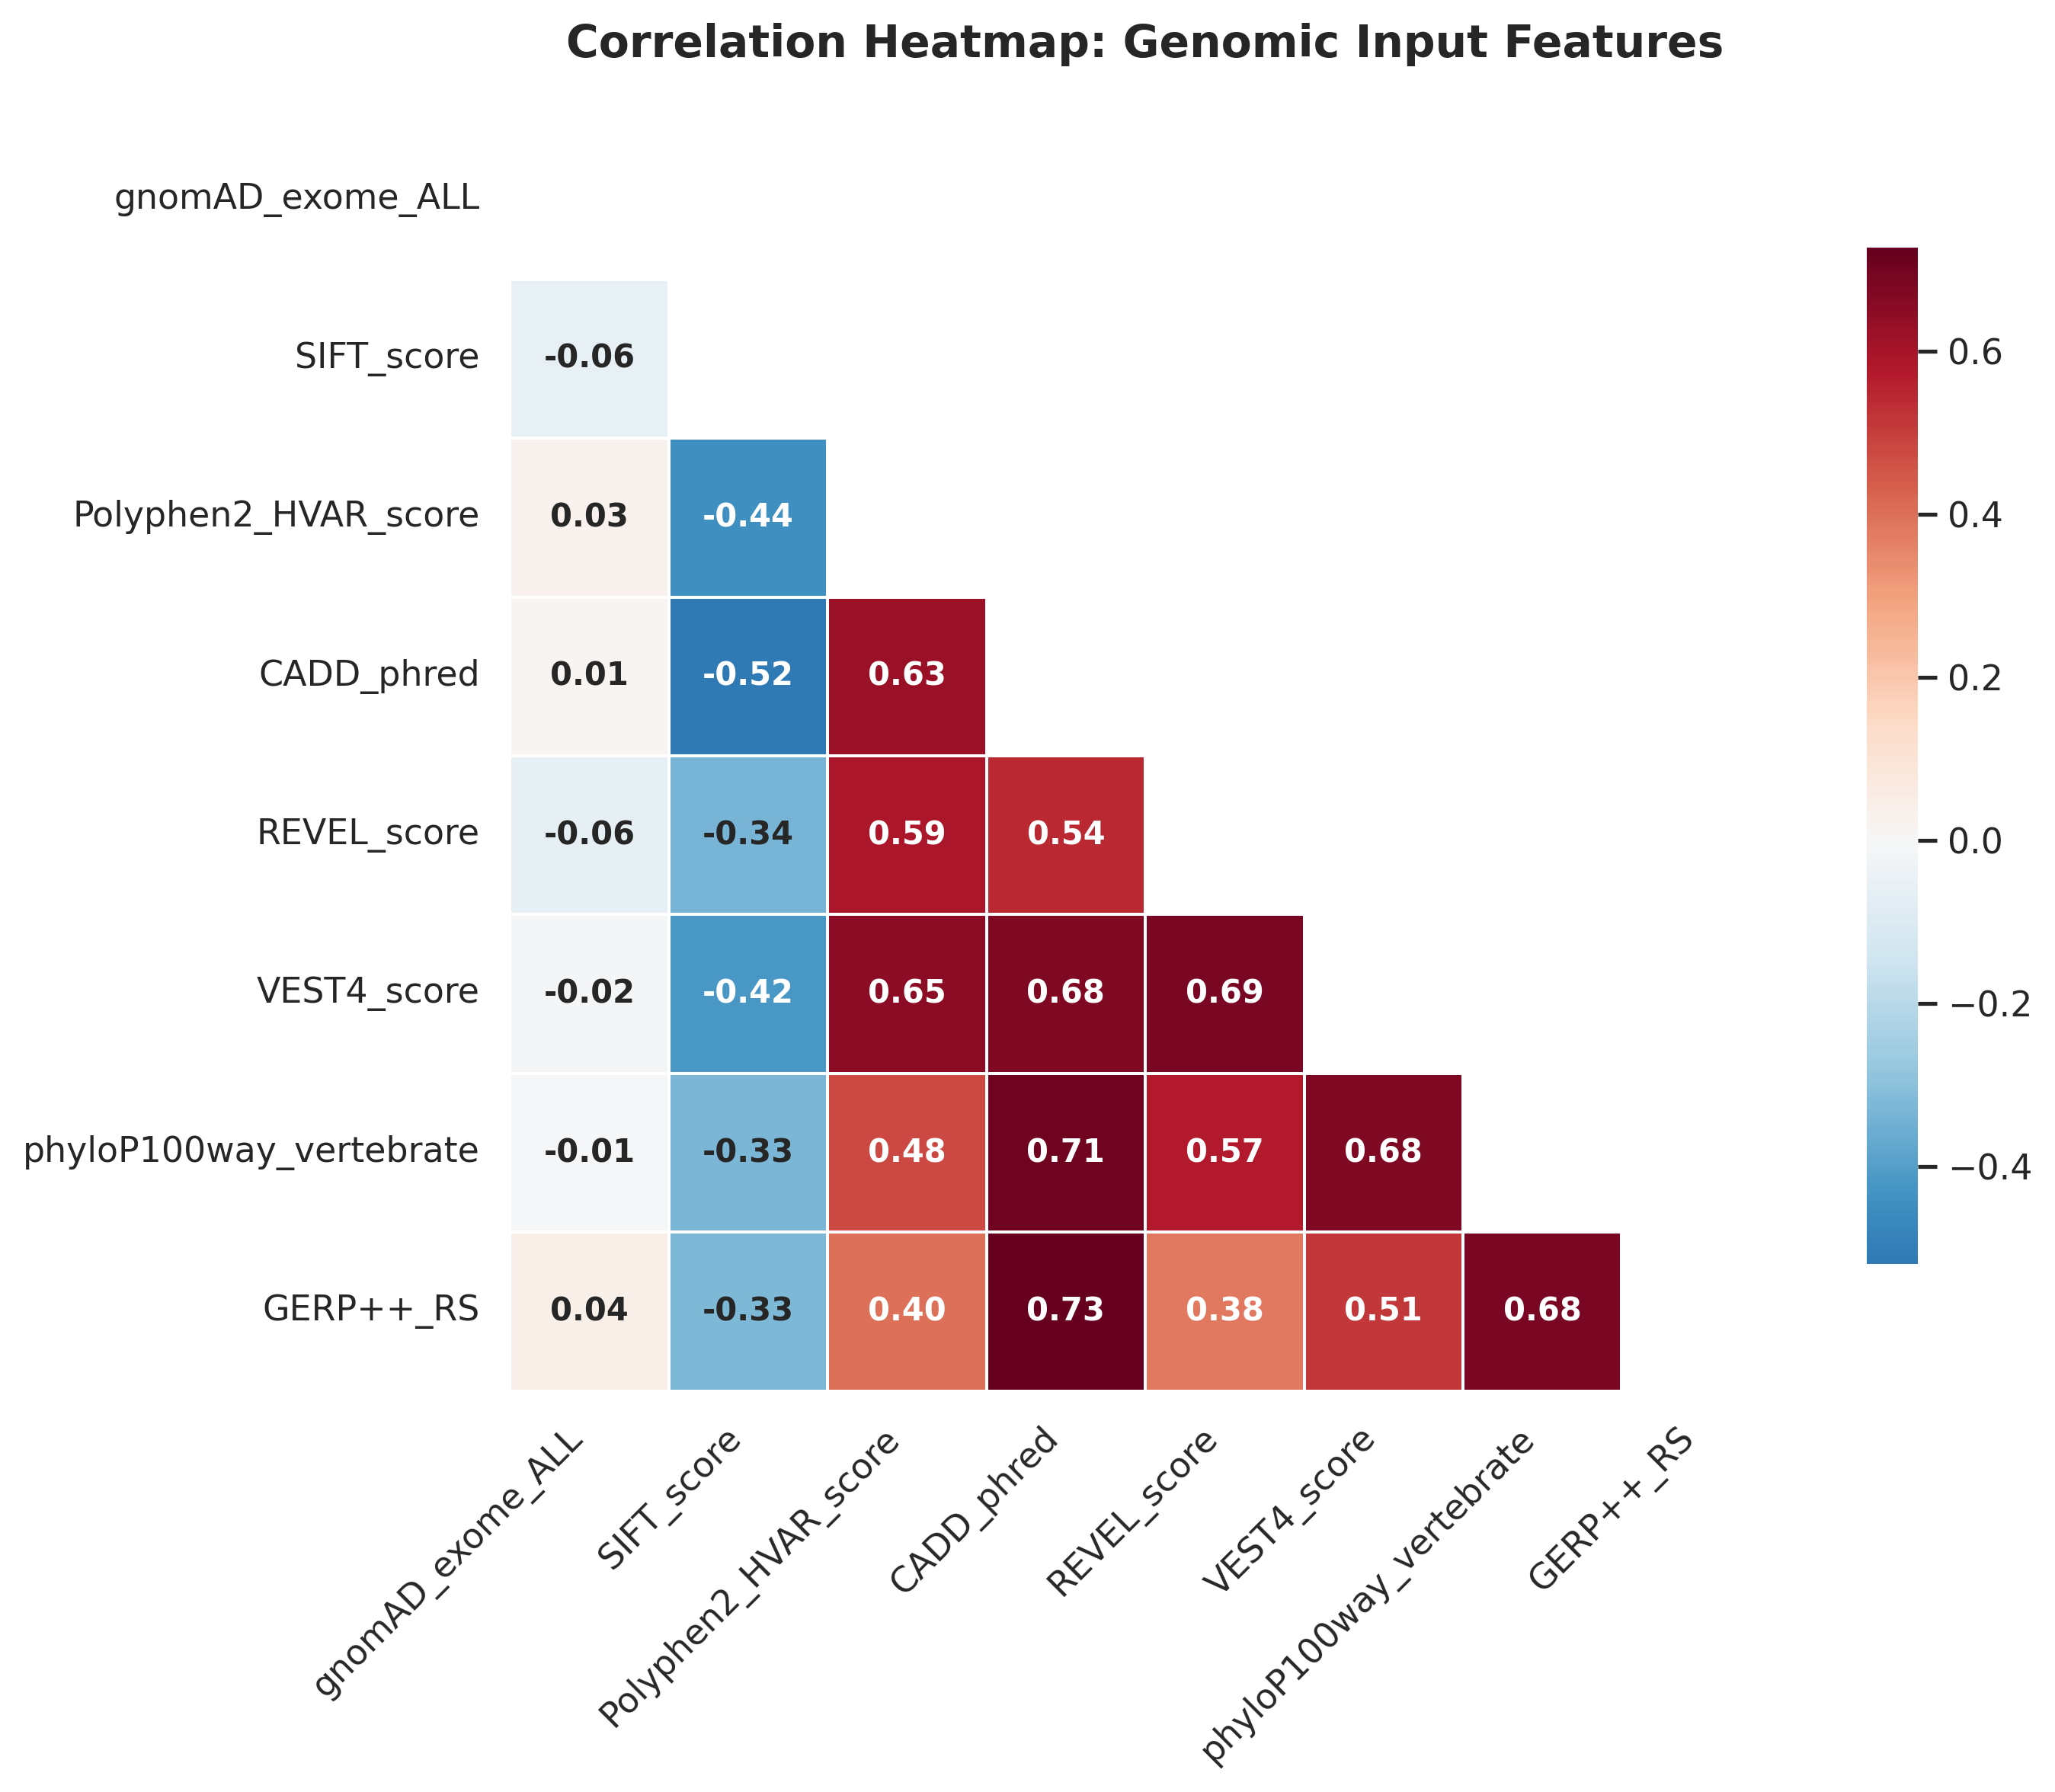

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate the correlation matrix for the features
corr_matrix = X.corr()

# 2. Setup the plot aesthetics
plt.figure(figsize=(10, 8), dpi=300)
sns.set_theme(style='white')

# 3. Create a mask to hide the upper triangle (redundant information)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Plot the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10, "fontweight": "bold"}
)

plt.title('Correlation Heatmap: Genomic Input Features', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()